In [ ]:
# Importações
import sys
import os
import pathlib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src.utils.serialization import load_checkpoint
from src.utils.reprodutibility import set_seed

# Importar as funções
from src.result_analysis.plots import ( 
    plot_predictions_with_context,
    plot_metrics_by_horizon,
    plot_full_series_with_d1_forecast,
    plot_predictions_extremes
)

from src.result_analysis.metrics import (
    compute_flow_metrics,
    print_metrics_summary
)

from src import (
    ConfigLoader, load_feature_config, load_split_config, load_config,
    HydroDataset, create_temporal_split_with_gap,
    Seq2SeqHydro, train_model, predict_autoregressive,
    custom_collate_fn, get_device,
    compute_flow_metrics,
    print_metrics_summary,
    plot_predictions_with_context,
    plot_metrics_by_horizon
)


# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = root_folder / "models"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")

📁 Root folder: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo
📁 Config: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\config
📁 Processed data: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\data\processed


In [2]:
# Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

# Extrair configurações
stations = data_config["stations"]
flow_window_config = data_config["flow_window_config"]
climate_window_config = data_config["climate_window_config"]
temporal_features = data_config["temporal_features"]
api_k_list = data_config["feature_windows"]["api_k_list"]
static_keys = data_config["static_keys"]
static_attributes_dict = data_config["static_attributes"]  # ← NOVO

print(f"✓ {len(stations)} estações carregadas")
print(f"✓ Configurações de modelo carregadas")
print(f"✓ Configurações de treino carregadas")
print(f"✓ Atributos estáticos de {len(static_attributes_dict)} estações carregados")

# Célula 3: Carregar dados processados
print("\n📊 Carregando dados processados...")
features_file = PROCESSED_DIR / "features_combined.csv"

if not features_file.exists():
    raise FileNotFoundError(f"Arquivo de features não encontrado: {features_file}")

combined_df = pd.read_csv(features_file)
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df = combined_df.set_index('date')

print(f"✓ Dados carregados: {len(combined_df)} dias")
print(f"  Período: {combined_df.index.min().date()} a {combined_df.index.max().date()}")
print(f"  Colunas: {len(combined_df.columns)}")


⚙️ Carregando configurações...
✓ 3 estações carregadas
✓ Configurações de modelo carregadas
✓ Configurações de treino carregadas
✓ Atributos estáticos de 3 estações carregados

📊 Carregando dados processados...
✓ Dados carregados: 6330 dias
  Período: 1995-01-01 a 2012-04-30
  Colunas: 142


In [3]:
MODELS_DIR = root_folder / "models/modelo_hidrologico_v1.pth"

# Configuração
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Carregar Modelo e Metadados
print("📂 Carregando checkpoint...")
model, meta = load_checkpoint(MODELS_DIR, device=DEVICE)

📂 Carregando checkpoint...
⚠️ Aviso: Carregamento seguro falhou (Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check t

In [5]:
# Criar forecast columns (mesmos dados para início)
forecast_cols = {}
for station in stations:
    forecast_cols[station] = (
        f'precipitation_forecast_{station}',
        f'potential_evapotransp_forecast_{station}'
    )

# 3. Criar o Dataset de Inferência
print("📦 Criando dataset de inferência...")
# Nota: Passamos train_indices=[0] apenas para satisfazer o construtor,
# pois logo em seguida vamos sobrescrever os scalers.
ds_inference = HydroDataset(
    df=combined_df,
    stations=data_config["stations"],
    static_attrs=static_attributes_dict, # Precisa ter este dicionário carregado
    train_indices=np.array([0]),         # Dummy index
    forecast_cols=forecast_cols,
    flow_window_config=data_config["flow_window_config"],
    climate_window_config=data_config["climate_window_config"],
    temporal_features=data_config["temporal_features"],
    api_k_list=[],                       # Não é mais usado
    static_keys=data_config["static_keys"],
)

# 4. 💉 INJEÇÃO DE SCALERS (Passo Crucial)
# Substituímos os scalers calculados no df_novo pelos scalers originais do treino.
# Isso garante que a normalização seja consistente.
# Usamos 'meta' que veio do load_checkpoint
ds_inference.flow_scalers = meta["flow_scalers"]
ds_inference.climate_scalers = meta["climate_scalers"]
ds_inference.static_scalers = meta["static_scalers"]

# 5. Criar Subset de Teste
# Definir as proporções conforme seu config
train_ratio = data_config["split_config"]["train_ratio"]
val_ratio = data_config["split_config"]["val_ratio"]
test_ratio = data_config["split_config"]["test_ratio"]

# Calcular os índices de corte
n_total = len(ds_inference)
train_end = int(n_total * train_ratio)
val_end = int(n_total * (train_ratio + val_ratio))

# Selecionar apenas os índices do conjunto de teste (últimos 2.5%)
test_indices = list(range(val_end, n_total))

print(f"📊 Total de amostras válidas: {n_total}")
print(f"🧪 Amostras de teste selecionadas: {len(test_indices)}")

ds_test = Subset(ds_inference, test_indices)

# 6. DataLoader (usando ds_test em vez de ds_inference)
dl_inference = DataLoader(
    ds_test,  # <--- Use o subset aqui
    batch_size=1, 
    shuffle=False, 
    collate_fn=custom_collate_fn
)

# 7. Executar Previsão
print("🔮 Gerando previsões apenas para o teste...")
preds, obs, baseline, g_seq, dates, _ = predict_autoregressive(
    model=model,
    loader=dl_inference, # Agora carrega apenas o teste
    decoder_history=meta["decoder_history"],
    decoder_horizon=meta["decoder_horizon"],
    scalers=meta["flow_scalers"],
    stations=data_config["stations"],
    clamp_non_negative=True,
    device=DEVICE
)

📦 Criando dataset de inferência...
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo

RuntimeError: input.size(-1) must be equal to input_size. Expected 24, got 21

📊 Calculando métricas...

RESUMO DAS MÉTRICAS POR ESTAÇÃO

📍 Estação 10100000
------------------------------------------------------------
  Overall:
    RMSE:       1269.545 m³/s
    MAE:        888.299 m³/s
    MAPE:       2.04%
    R²:         0.9749
    NSE:        0.9749
    KGE:        0.9120
    Skill RMSE: 0.5251

  Macro (ponderado por horizonte):
    RMSE:       1140.941 m³/s
    MAE:        888.299 m³/s
    MAPE:       2.04%
    R²:         0.9720
    NSE:        0.9720

📍 Estação 13150000
------------------------------------------------------------
  Overall:
    RMSE:       1203.362 m³/s
    MAE:        824.621 m³/s
    MAPE:       0.99%
    R²:         0.9962
    NSE:        0.9962
    KGE:        0.9865
    Skill RMSE: 0.7733

  Macro (ponderado por horizonte):
    RMSE:       1066.305 m³/s
    MAE:        824.621 m³/s
    MAPE:       0.99%
    R²:         0.9959
    NSE:        0.9959

📍 Estação 14100000
------------------------------------------------------------
  Ove

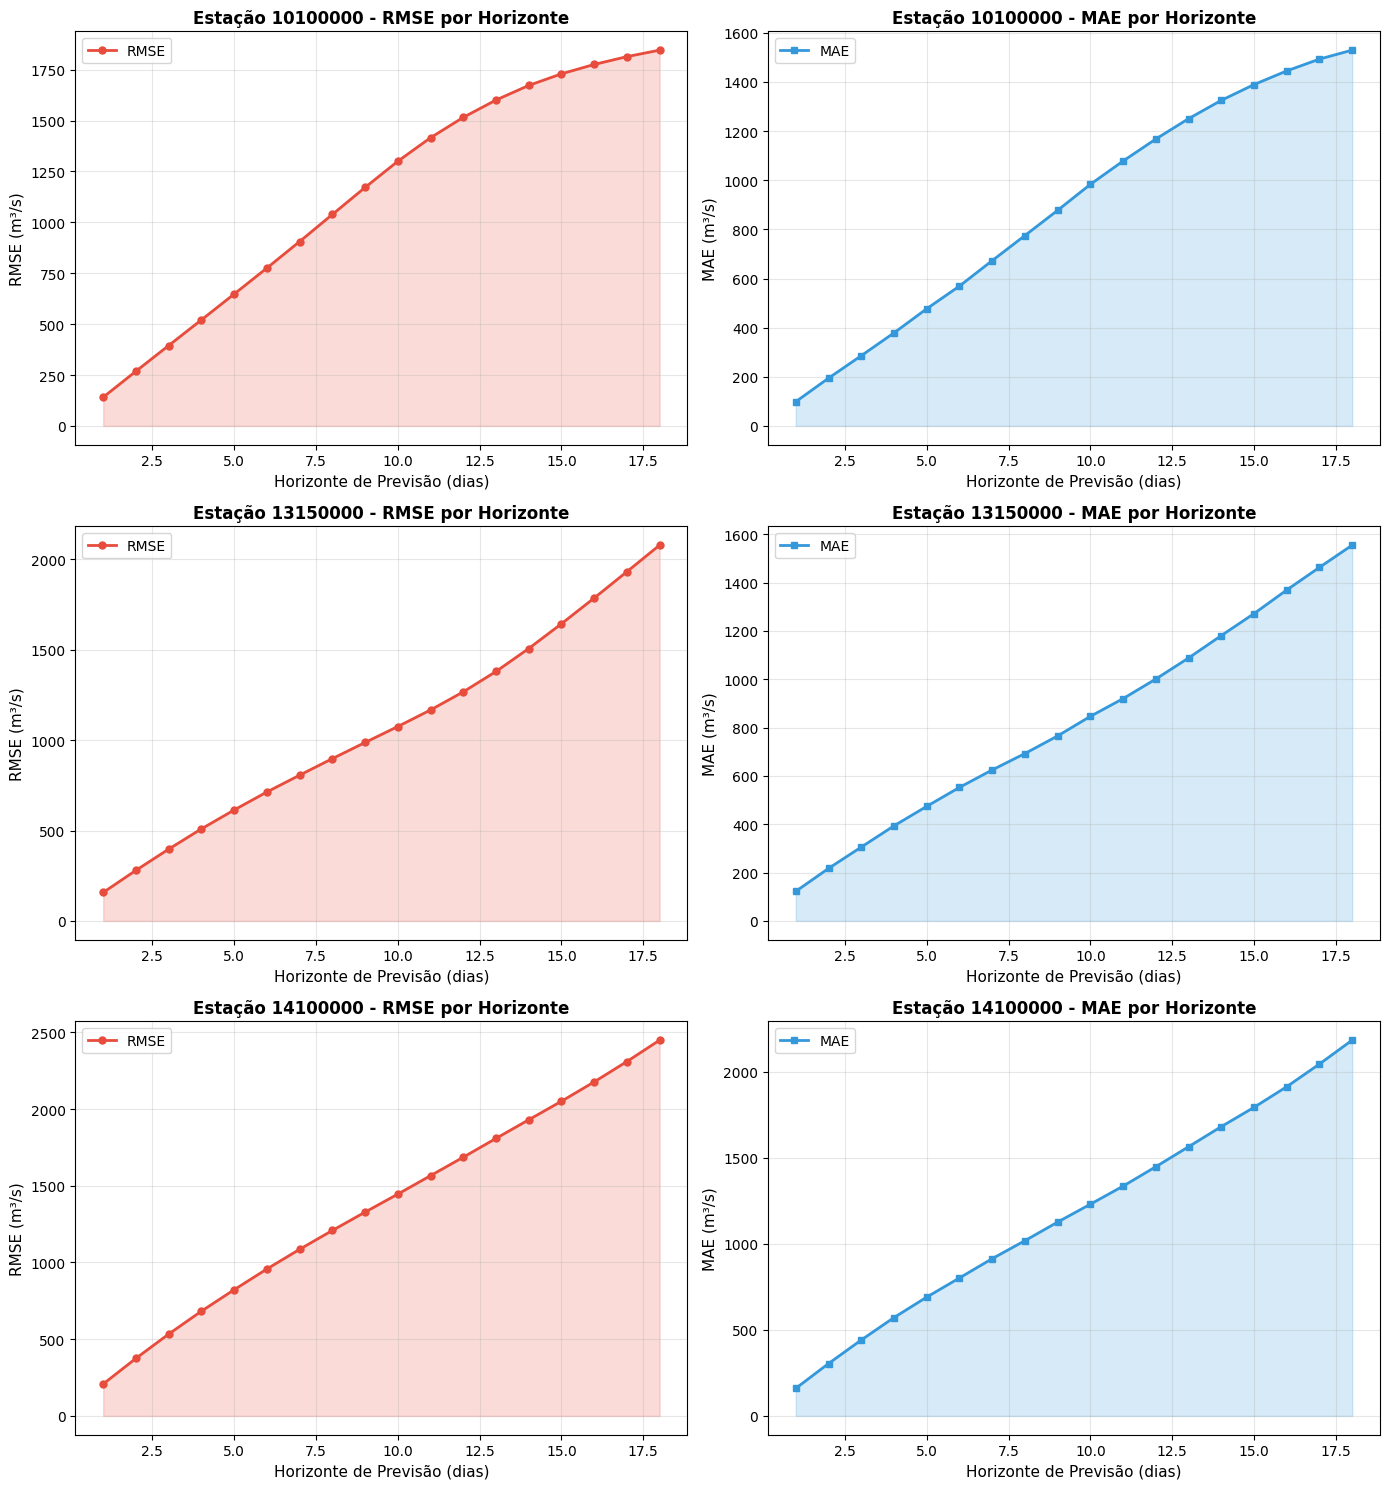

📈 Gerando gráficos de previsão...


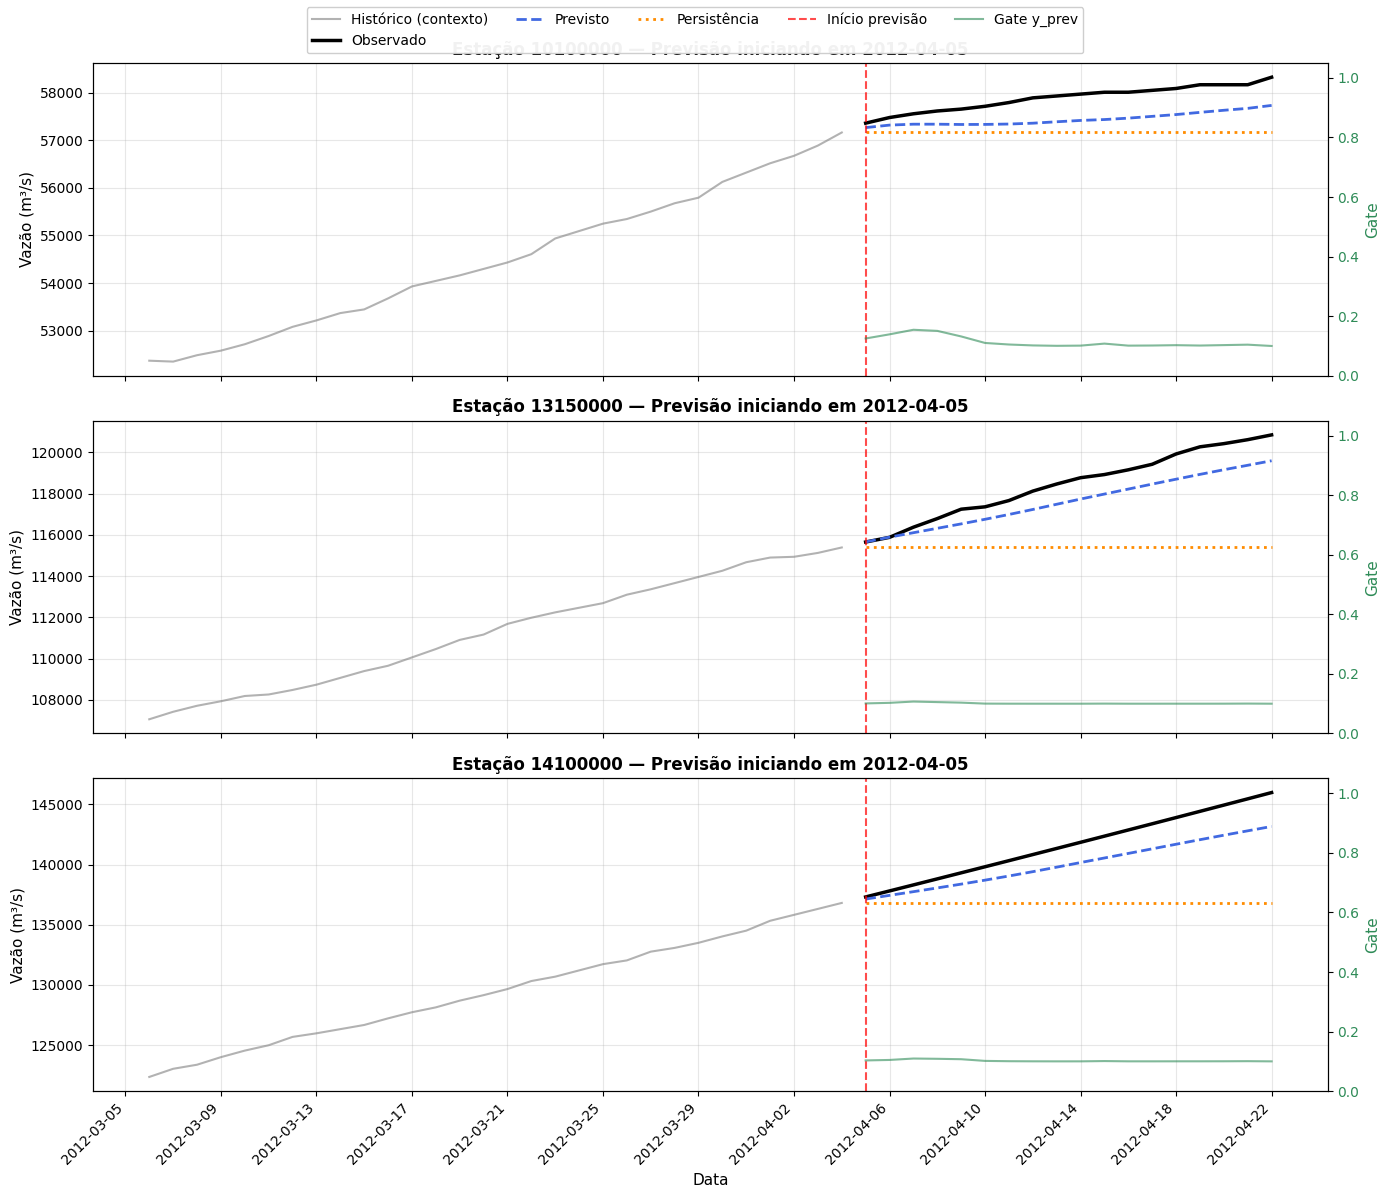

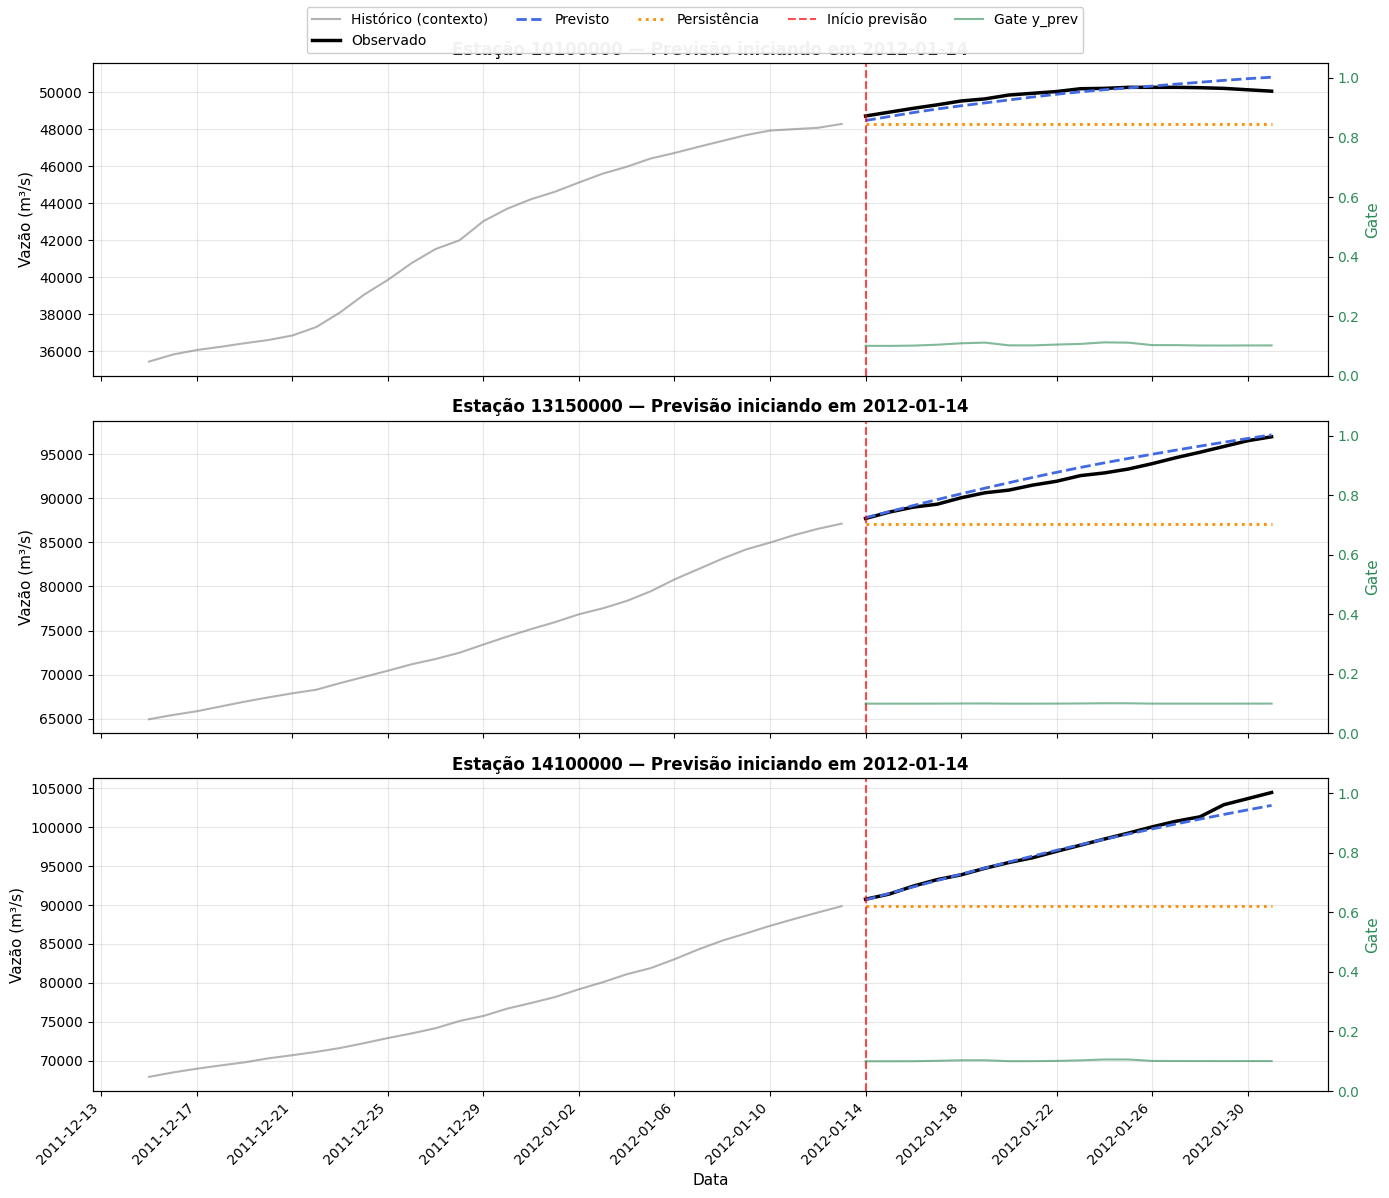

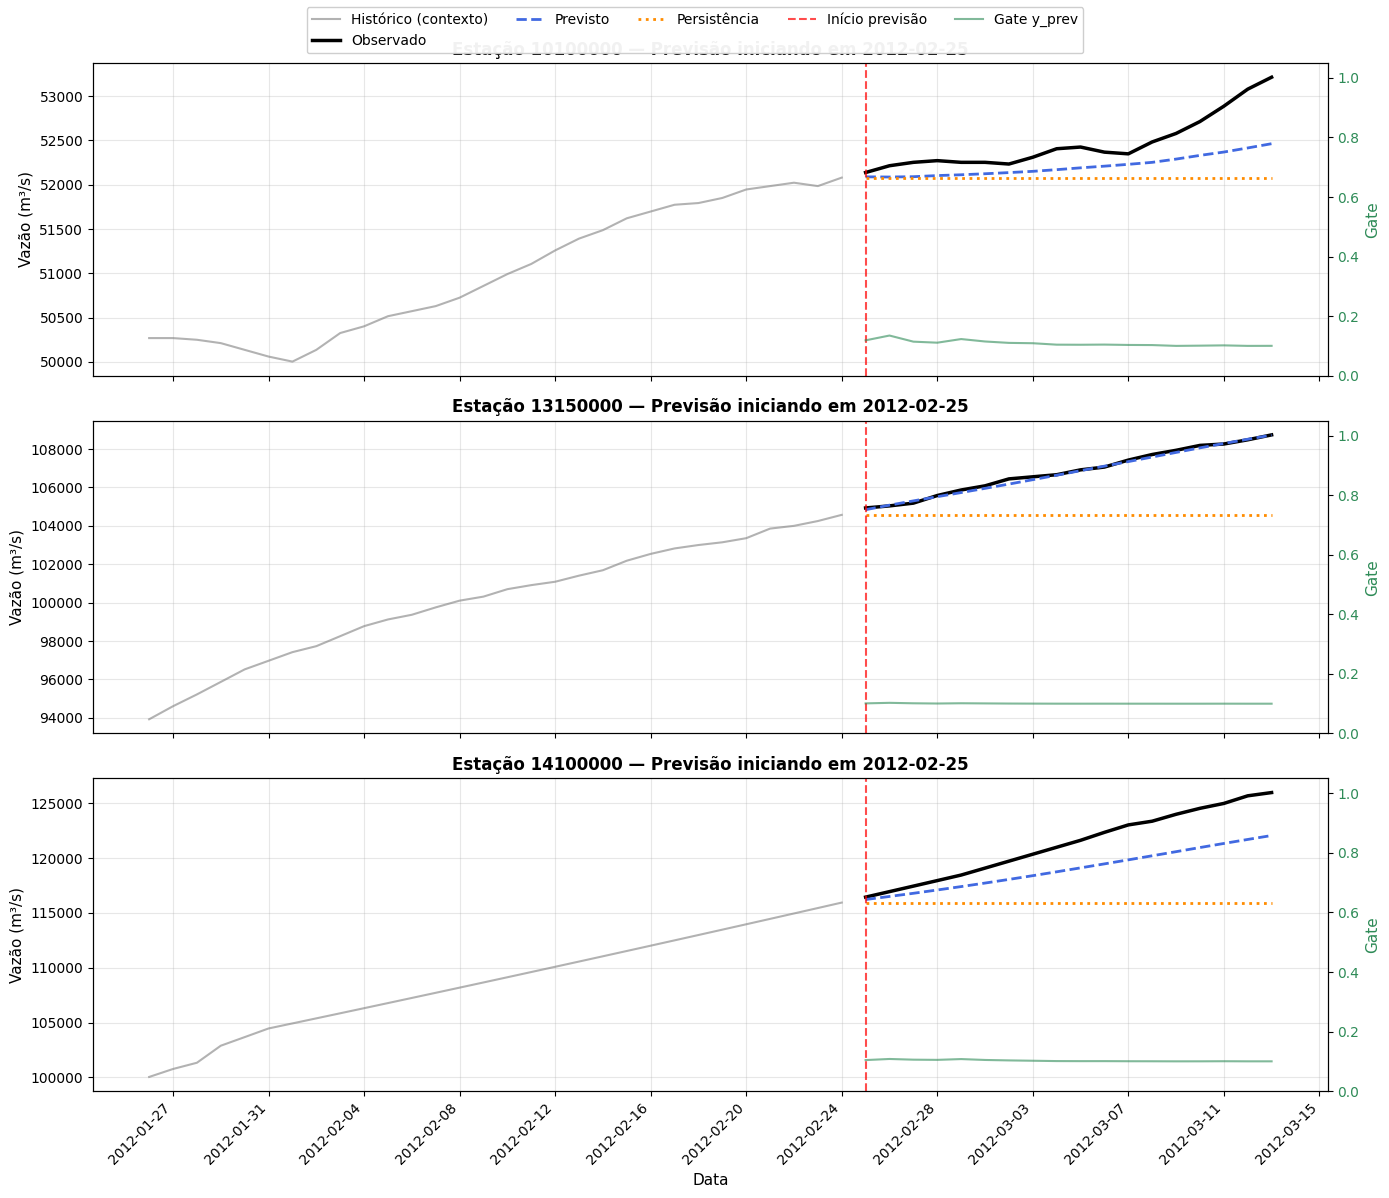

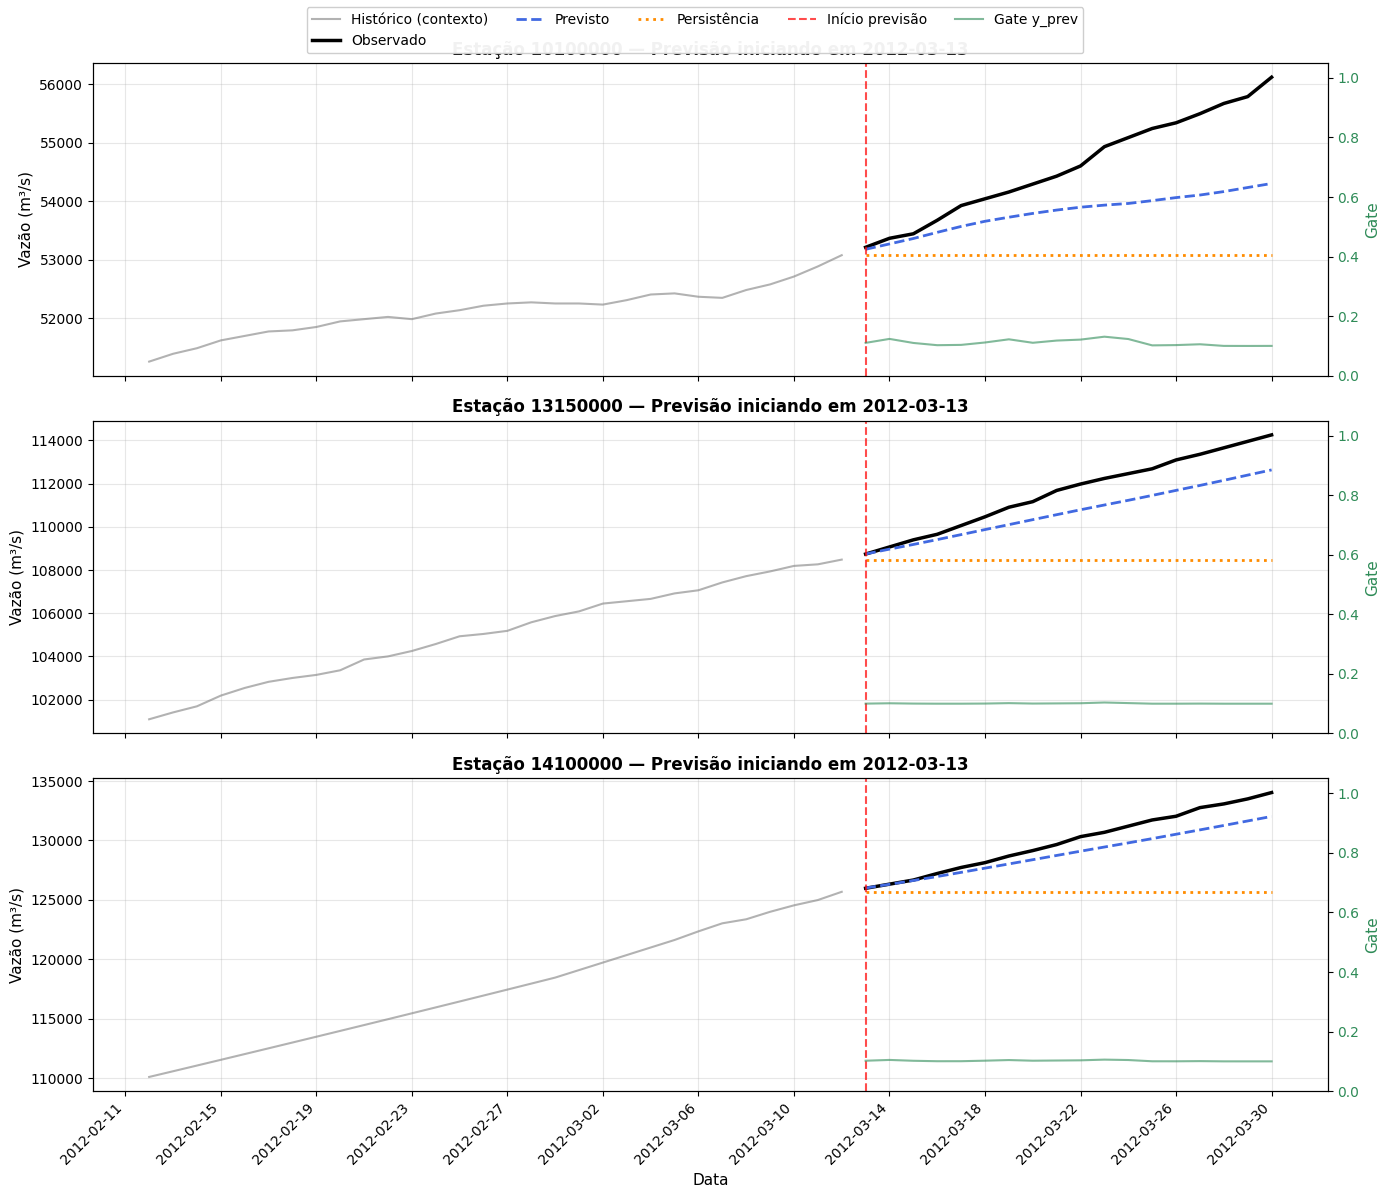

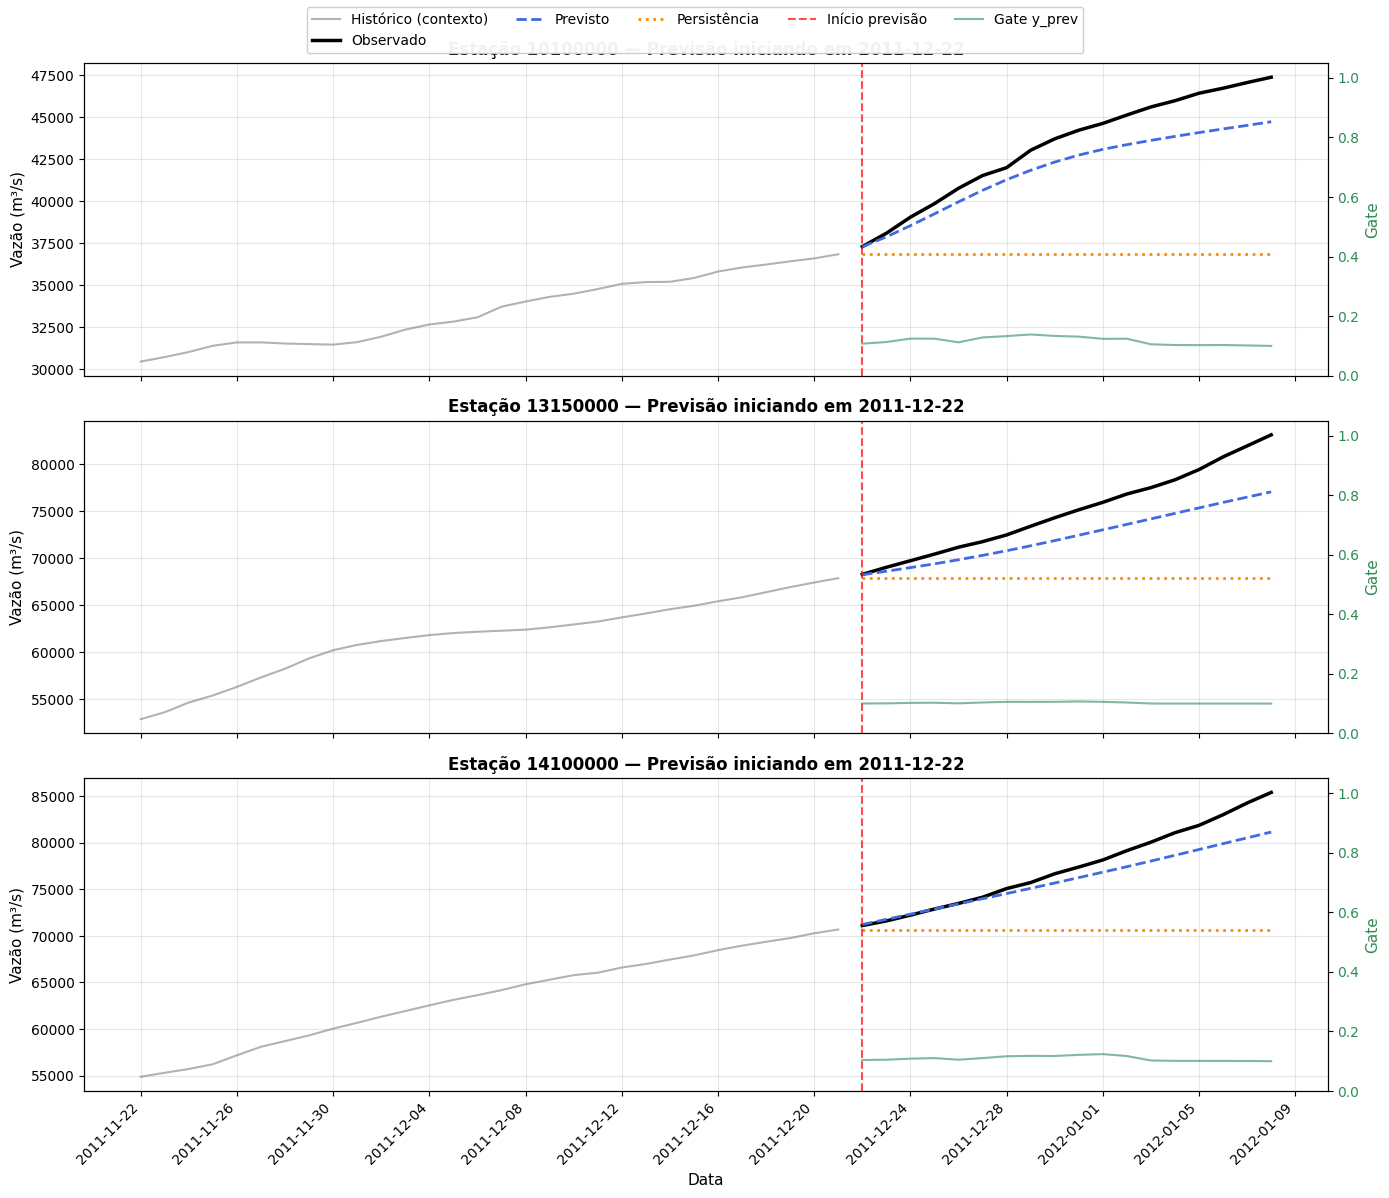

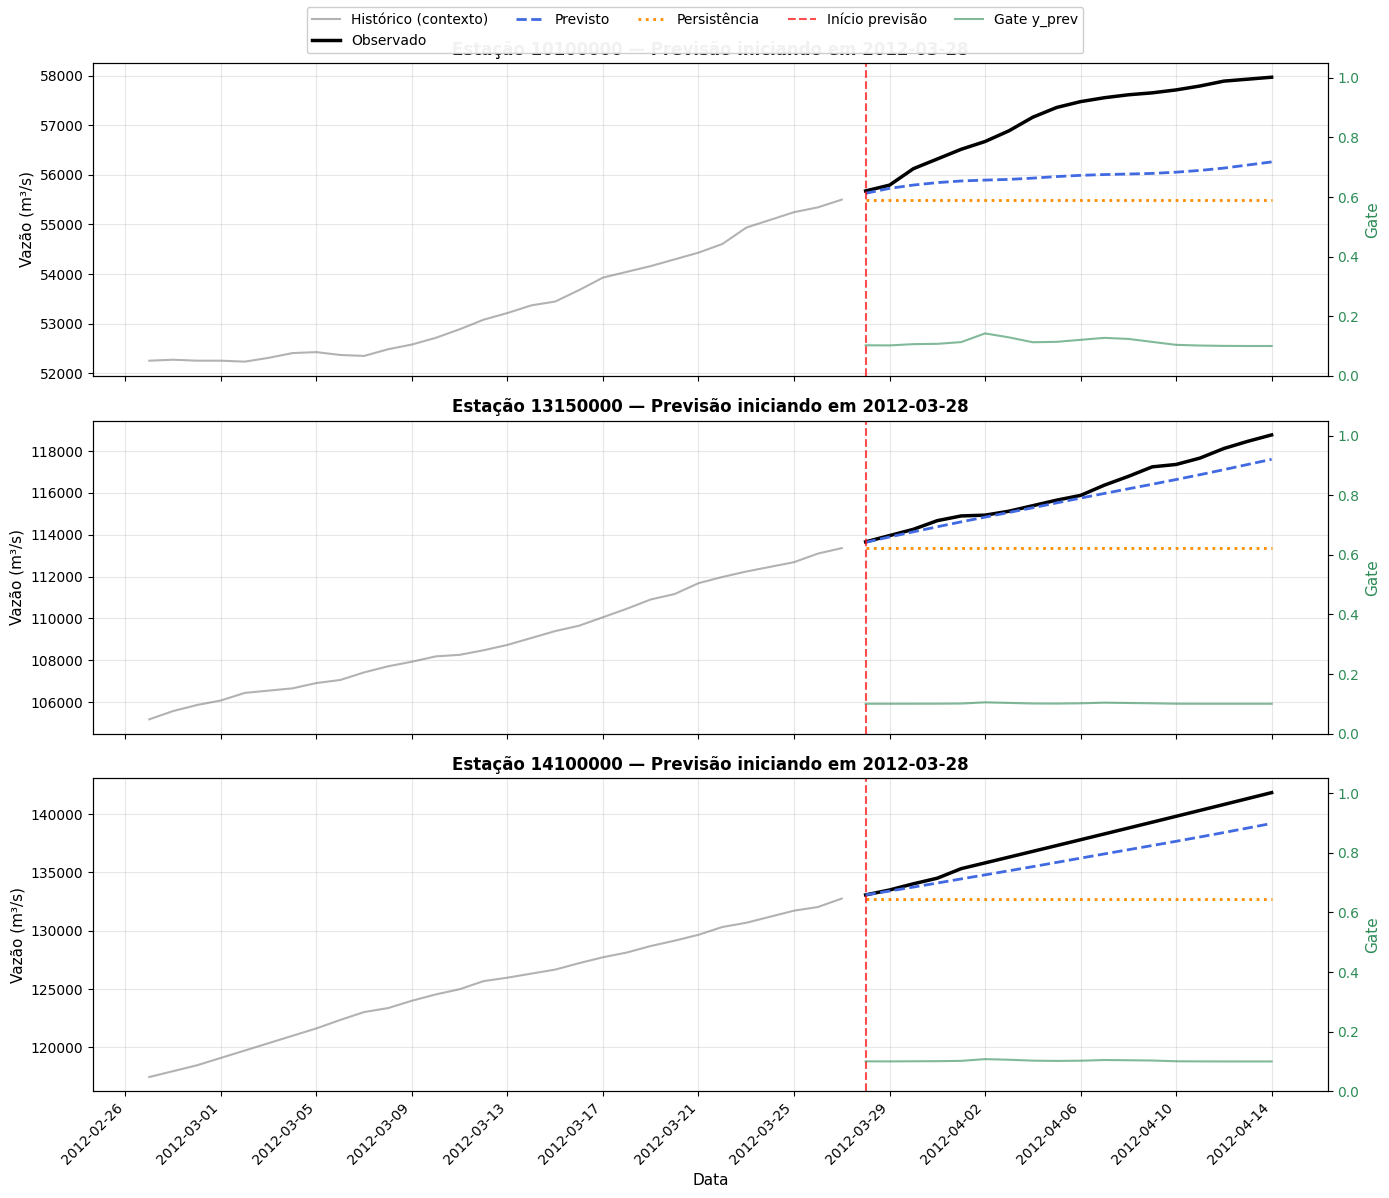

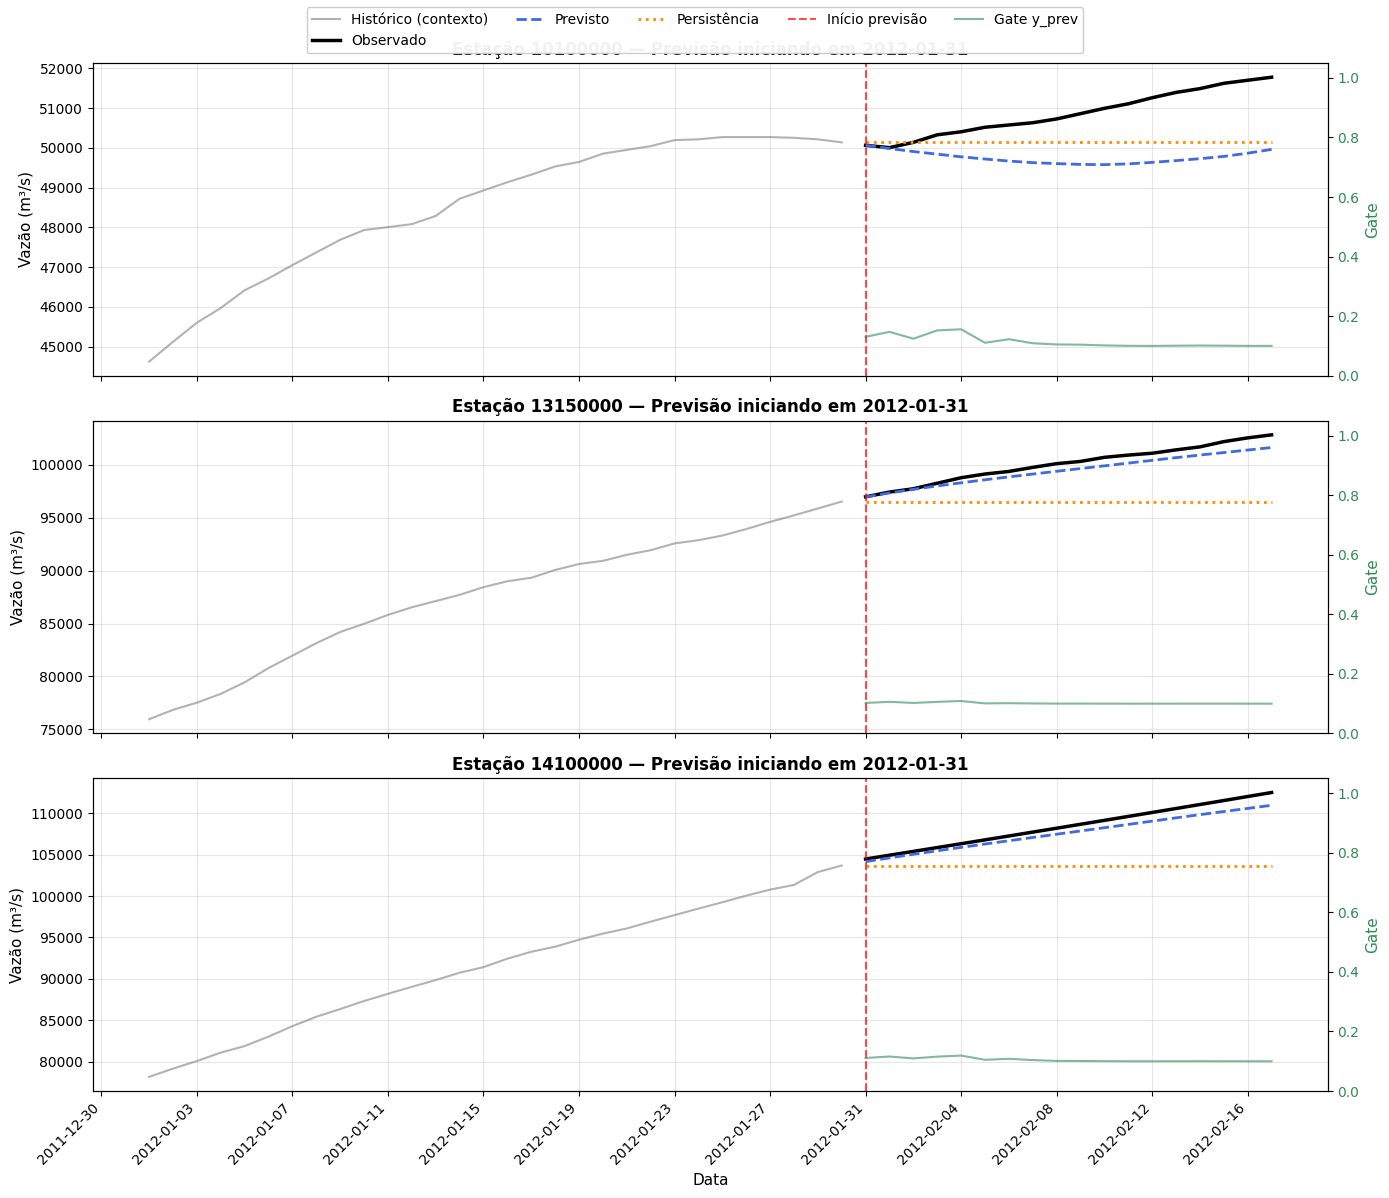

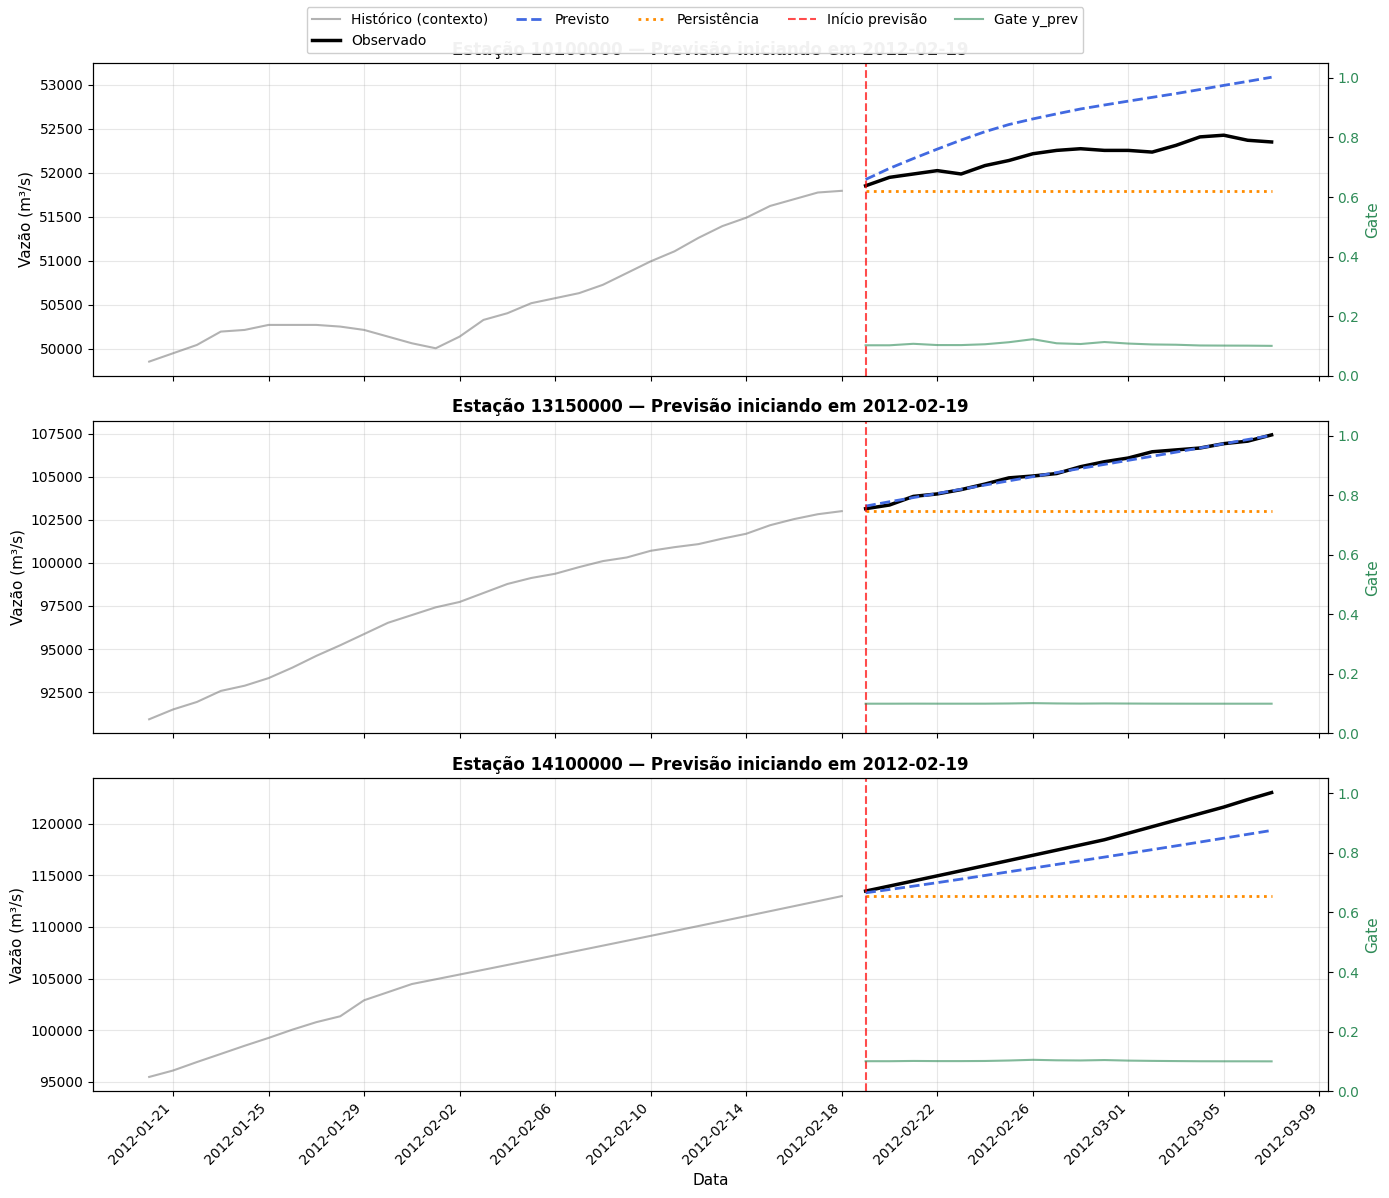

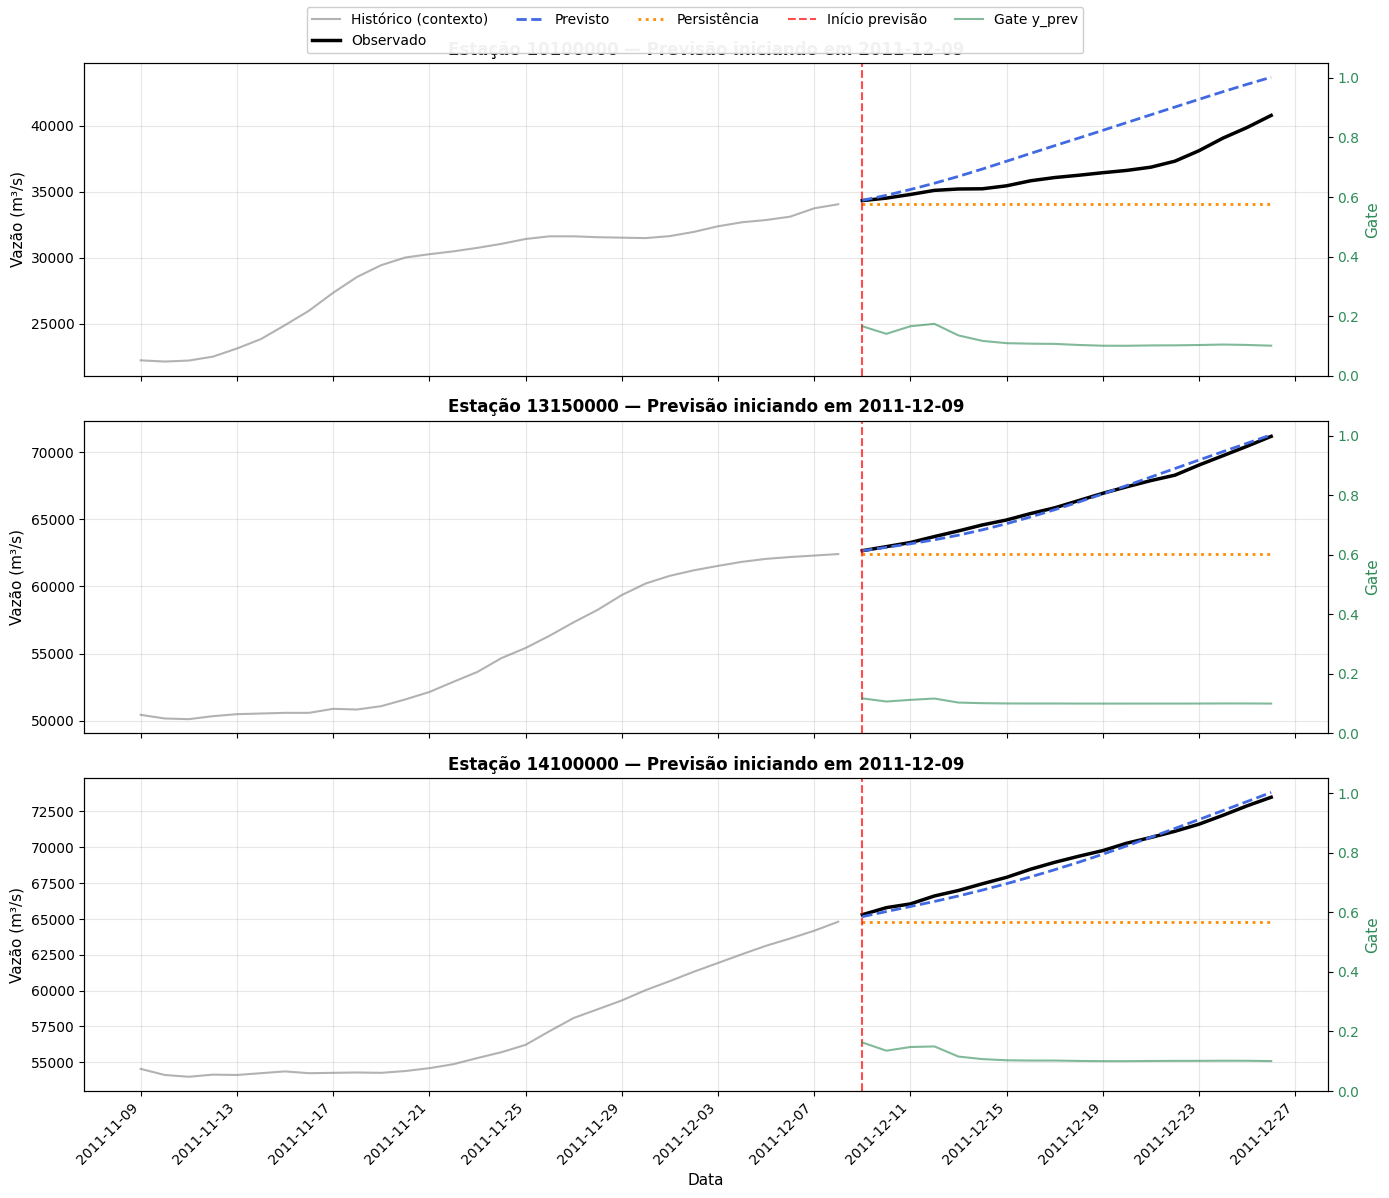

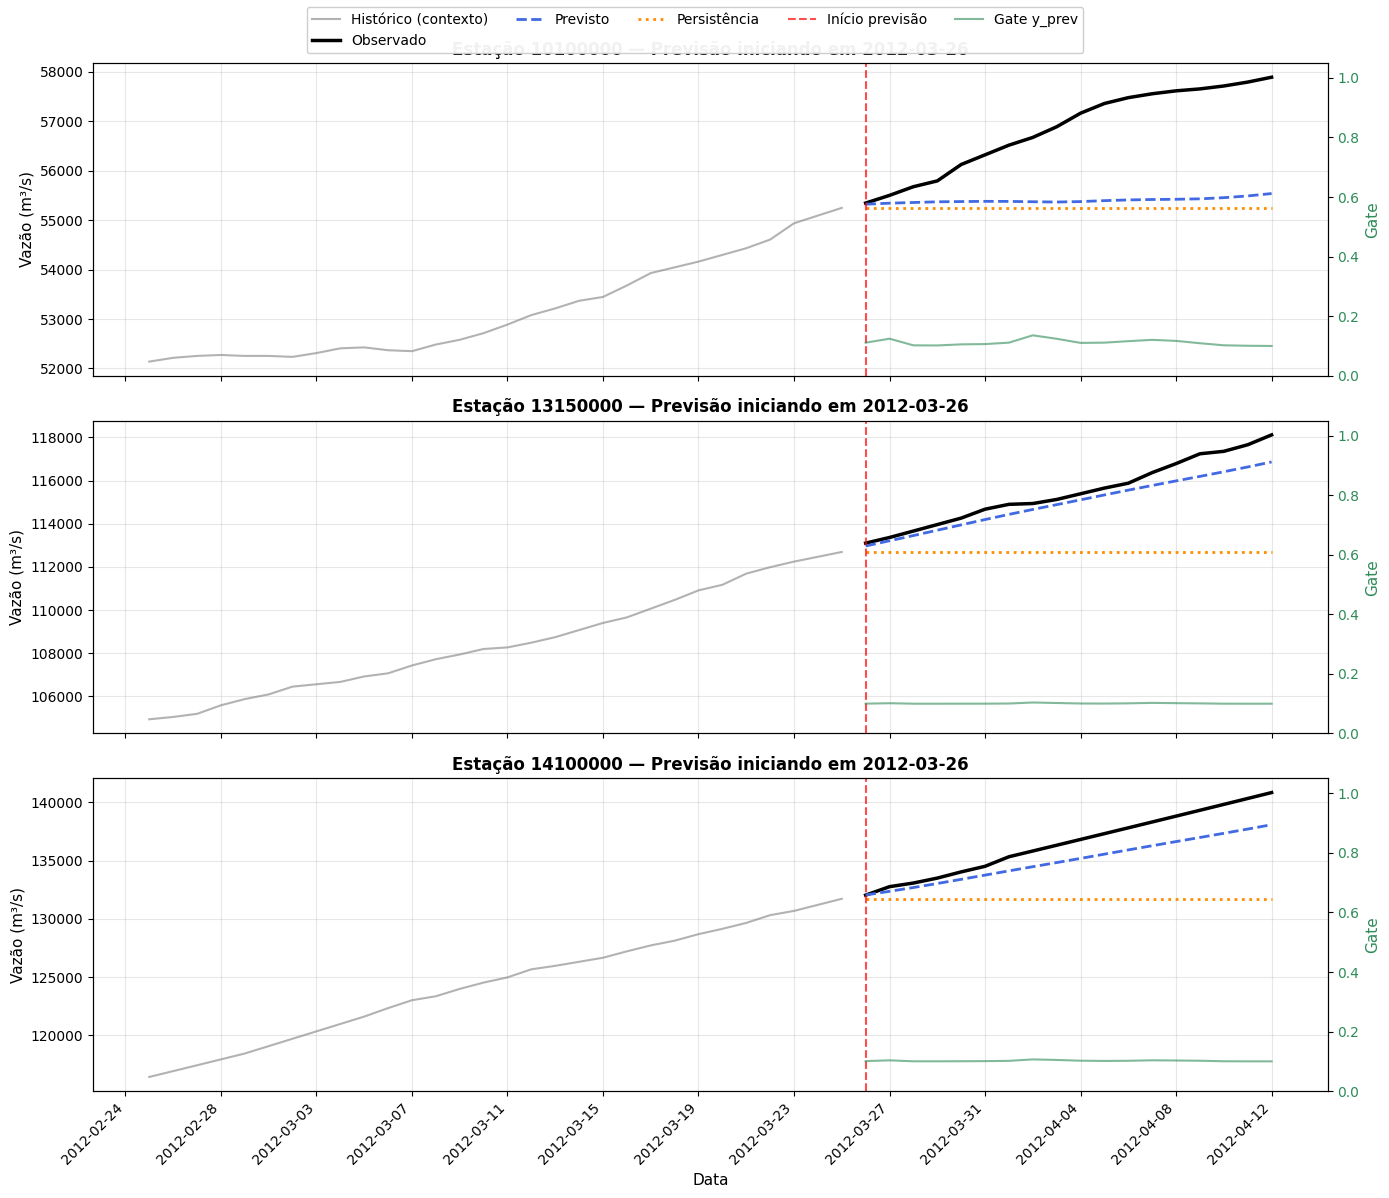

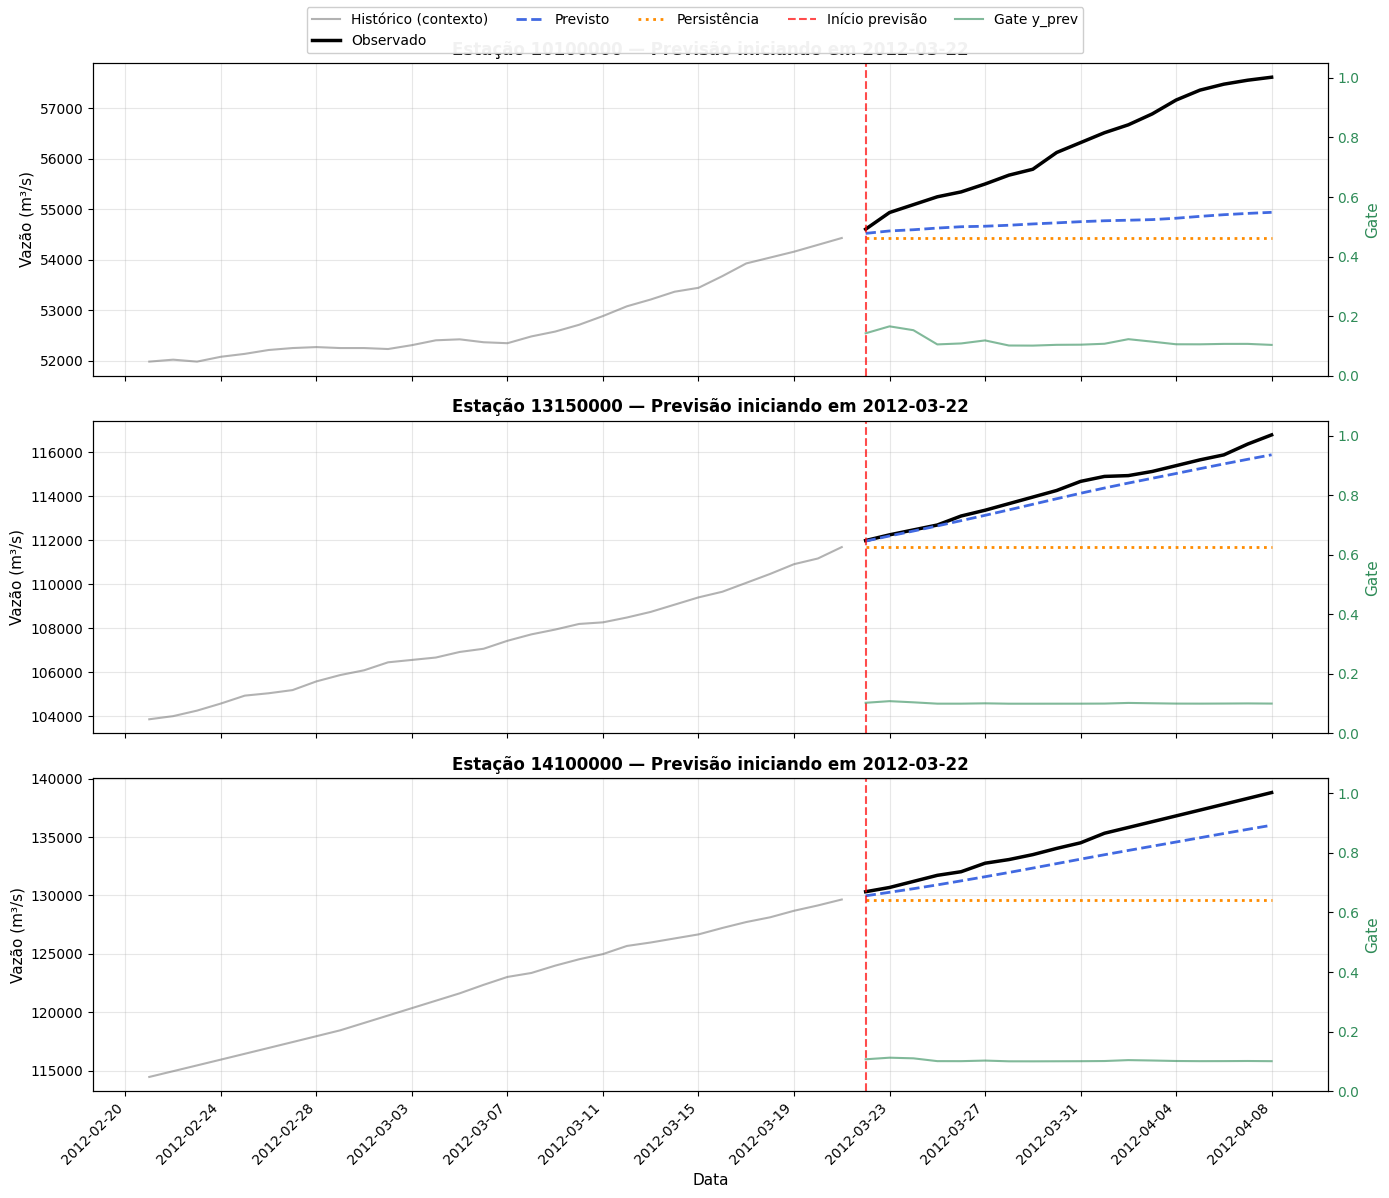

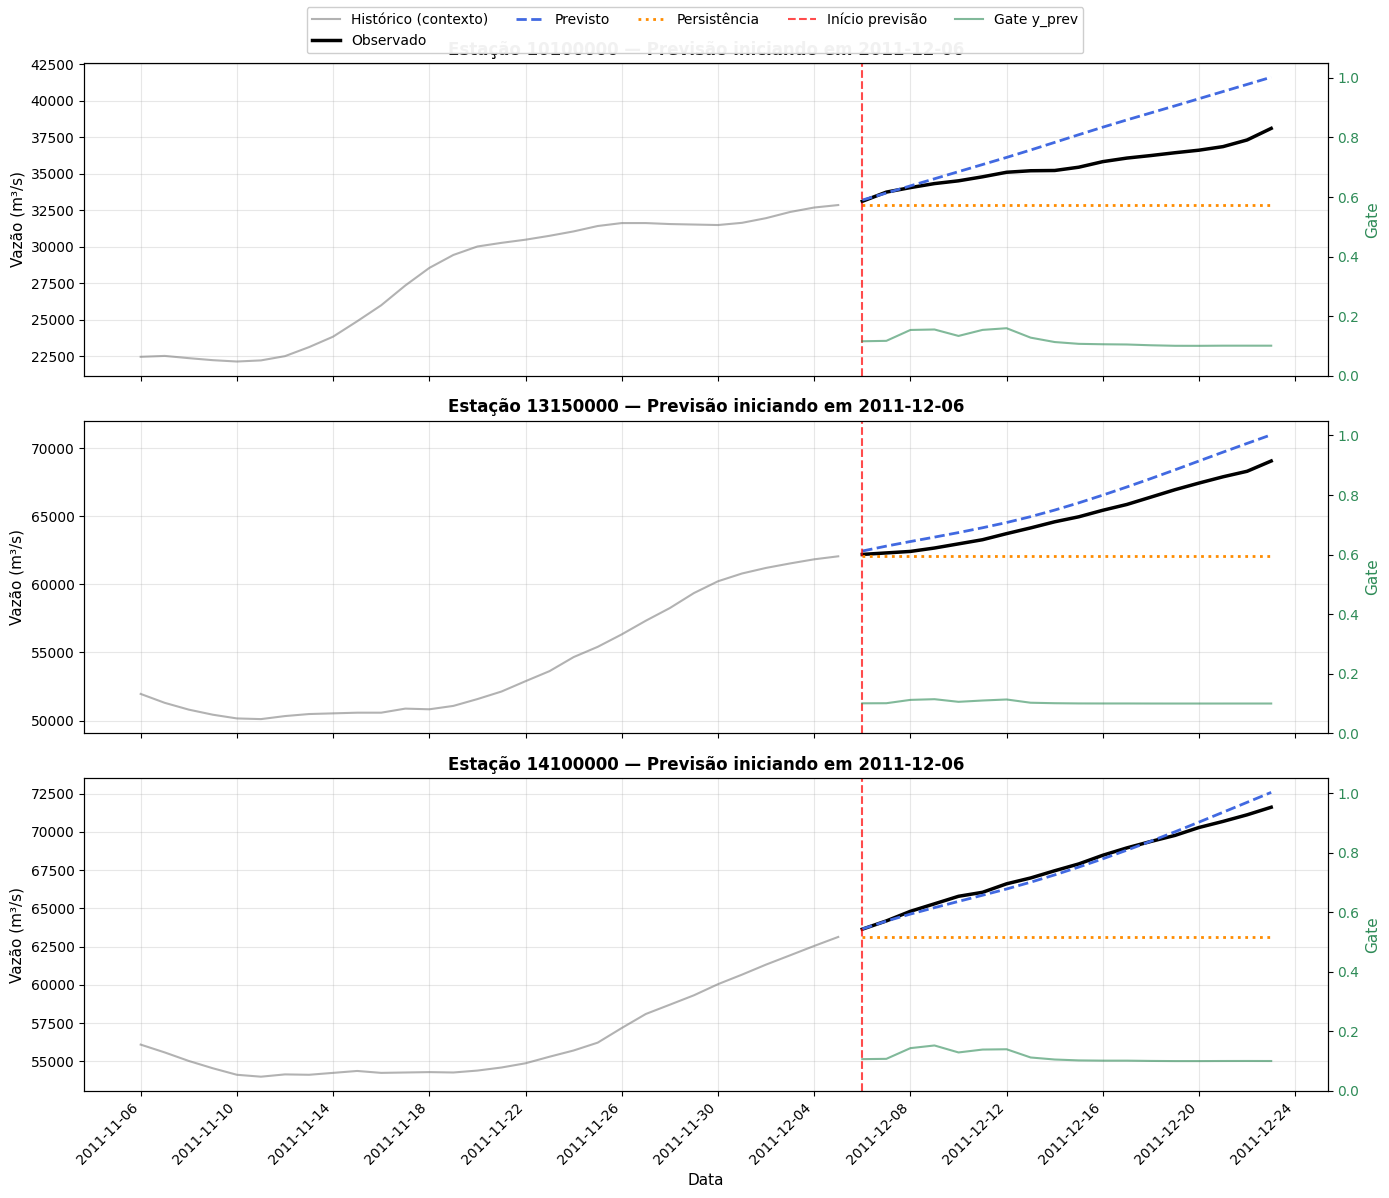

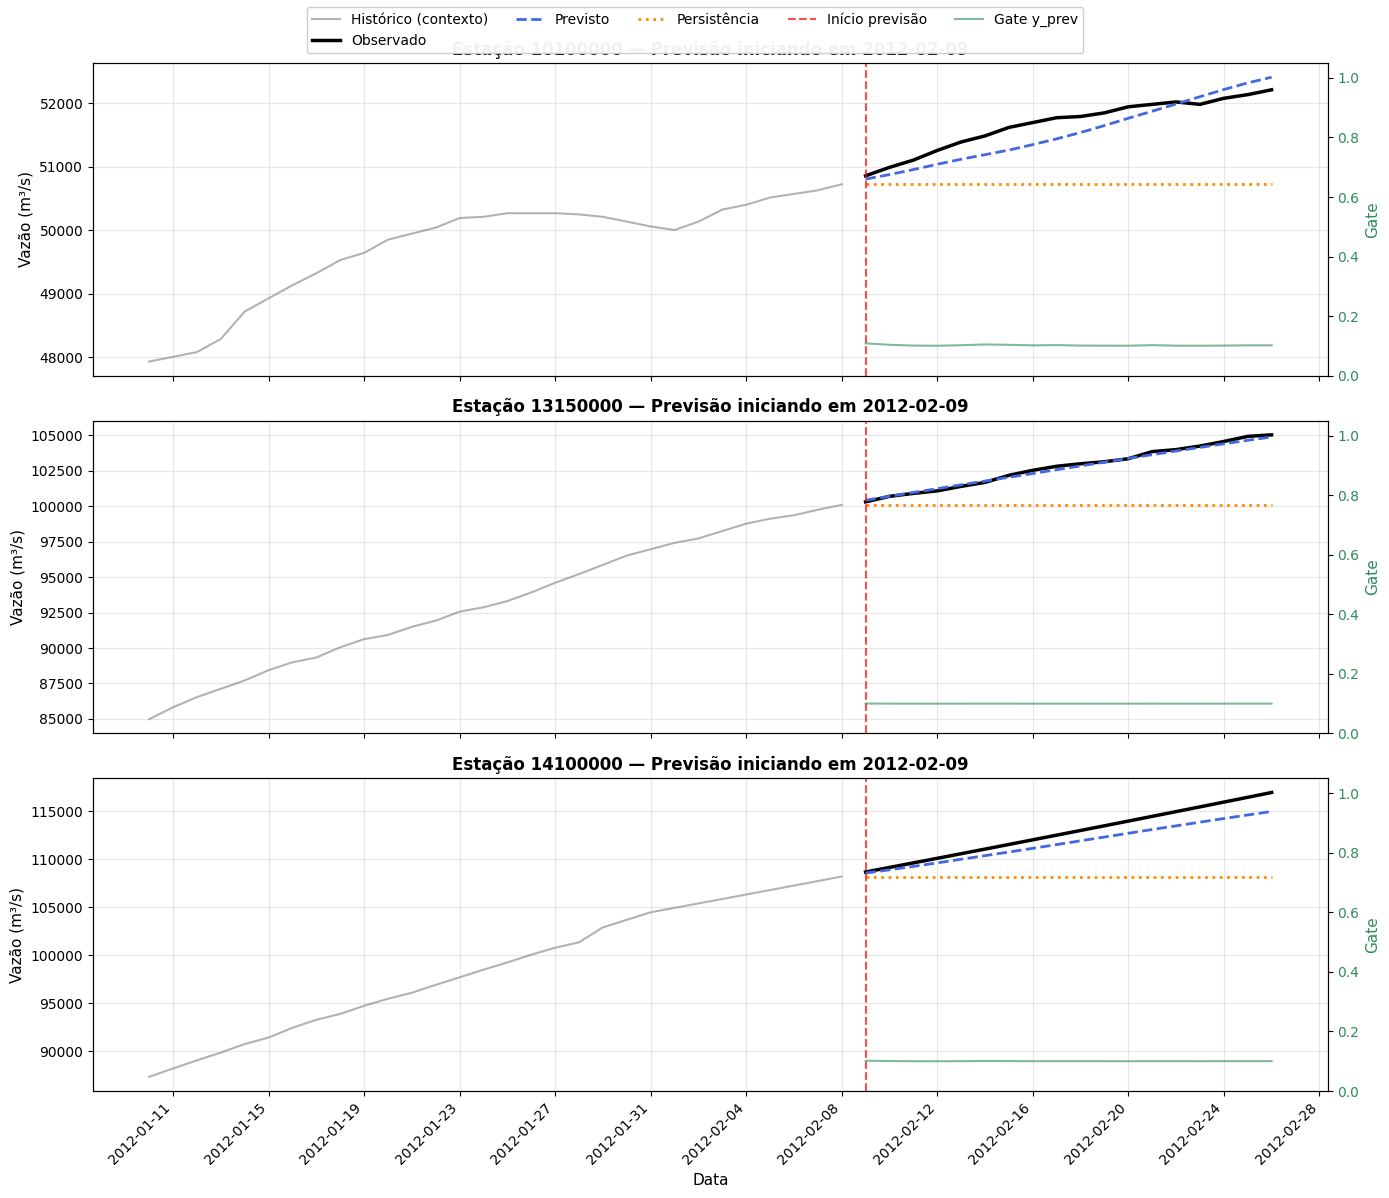

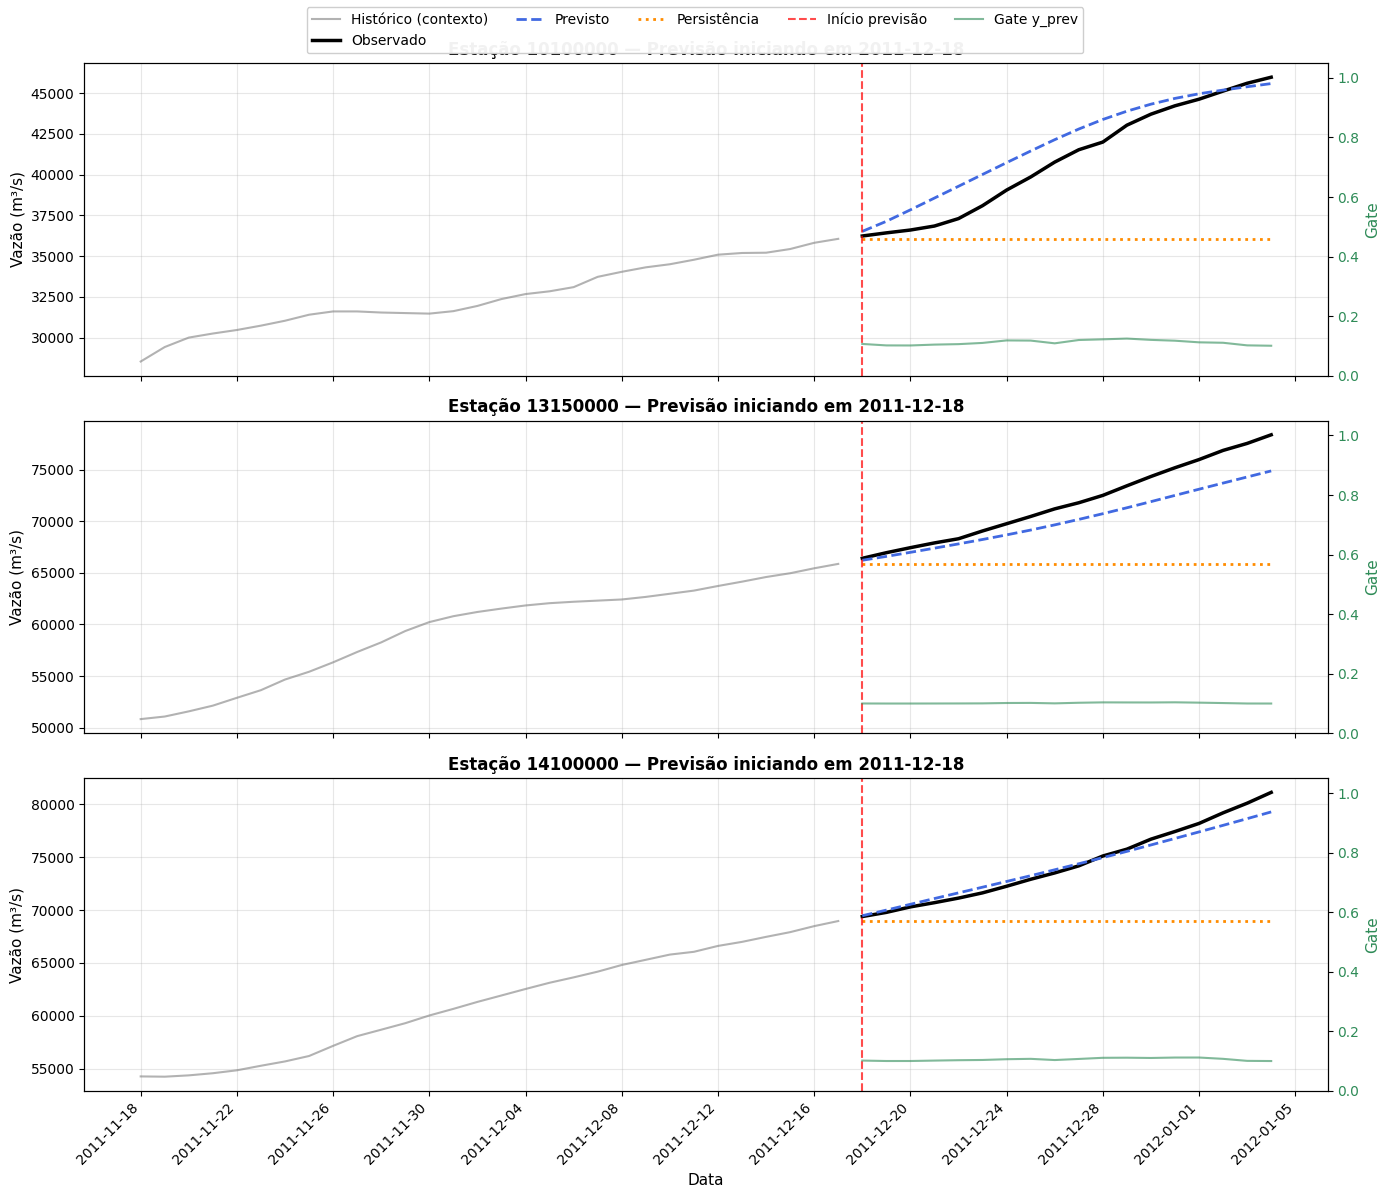

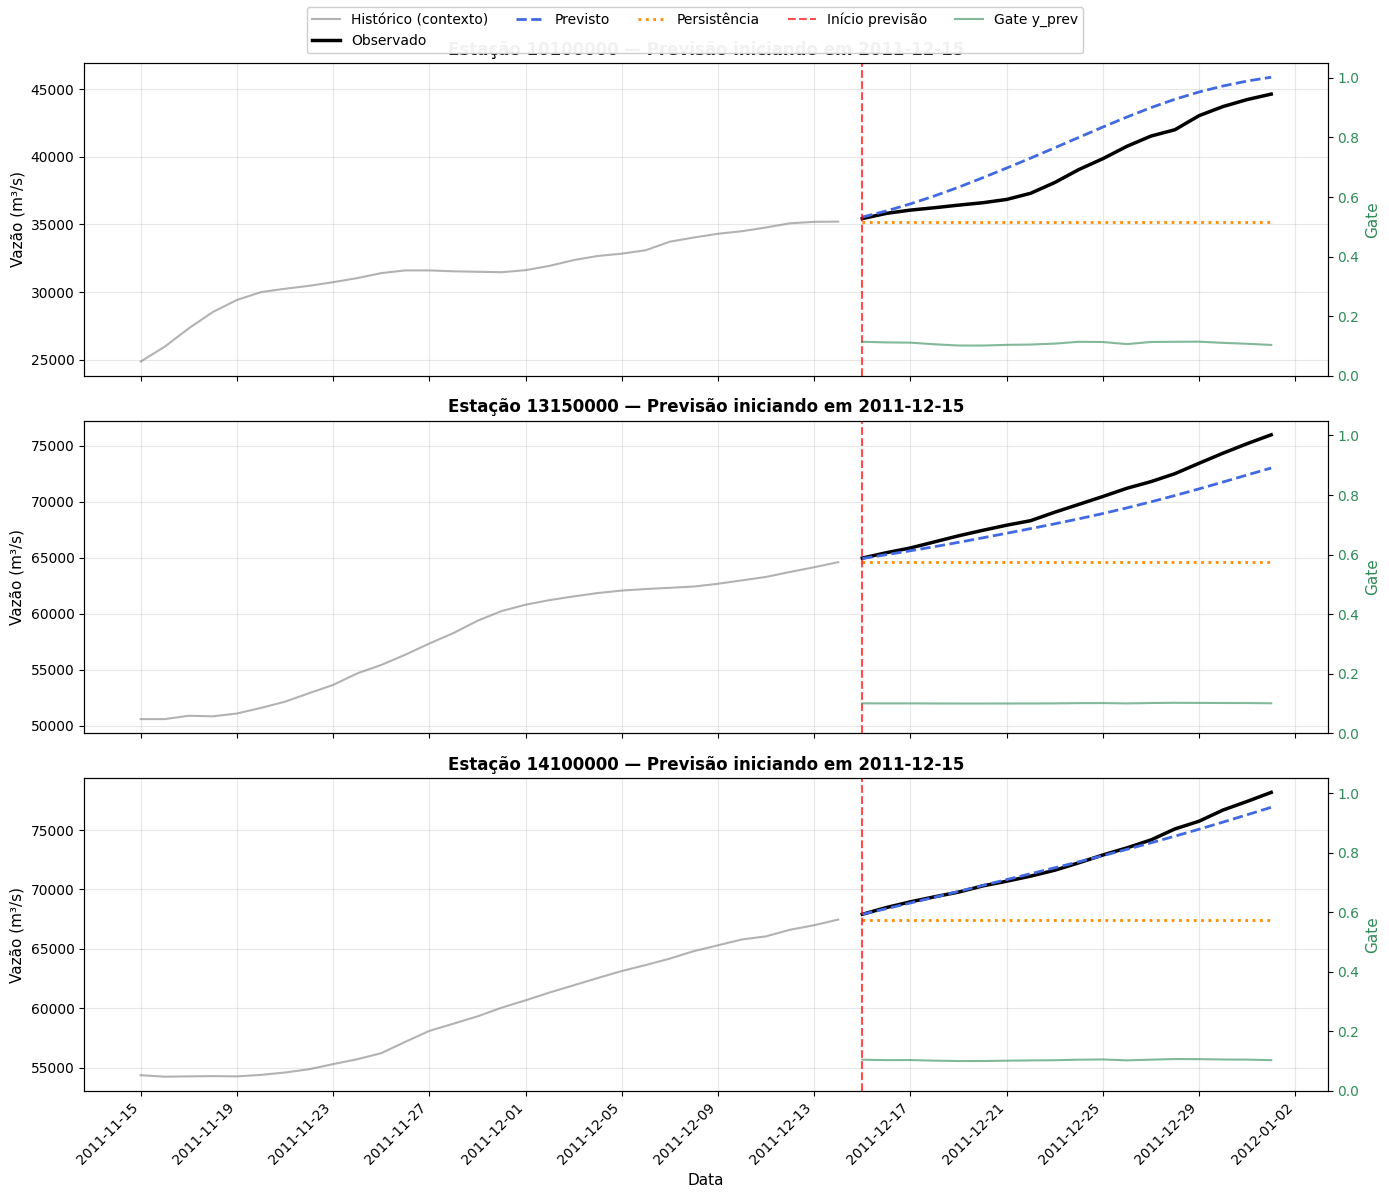

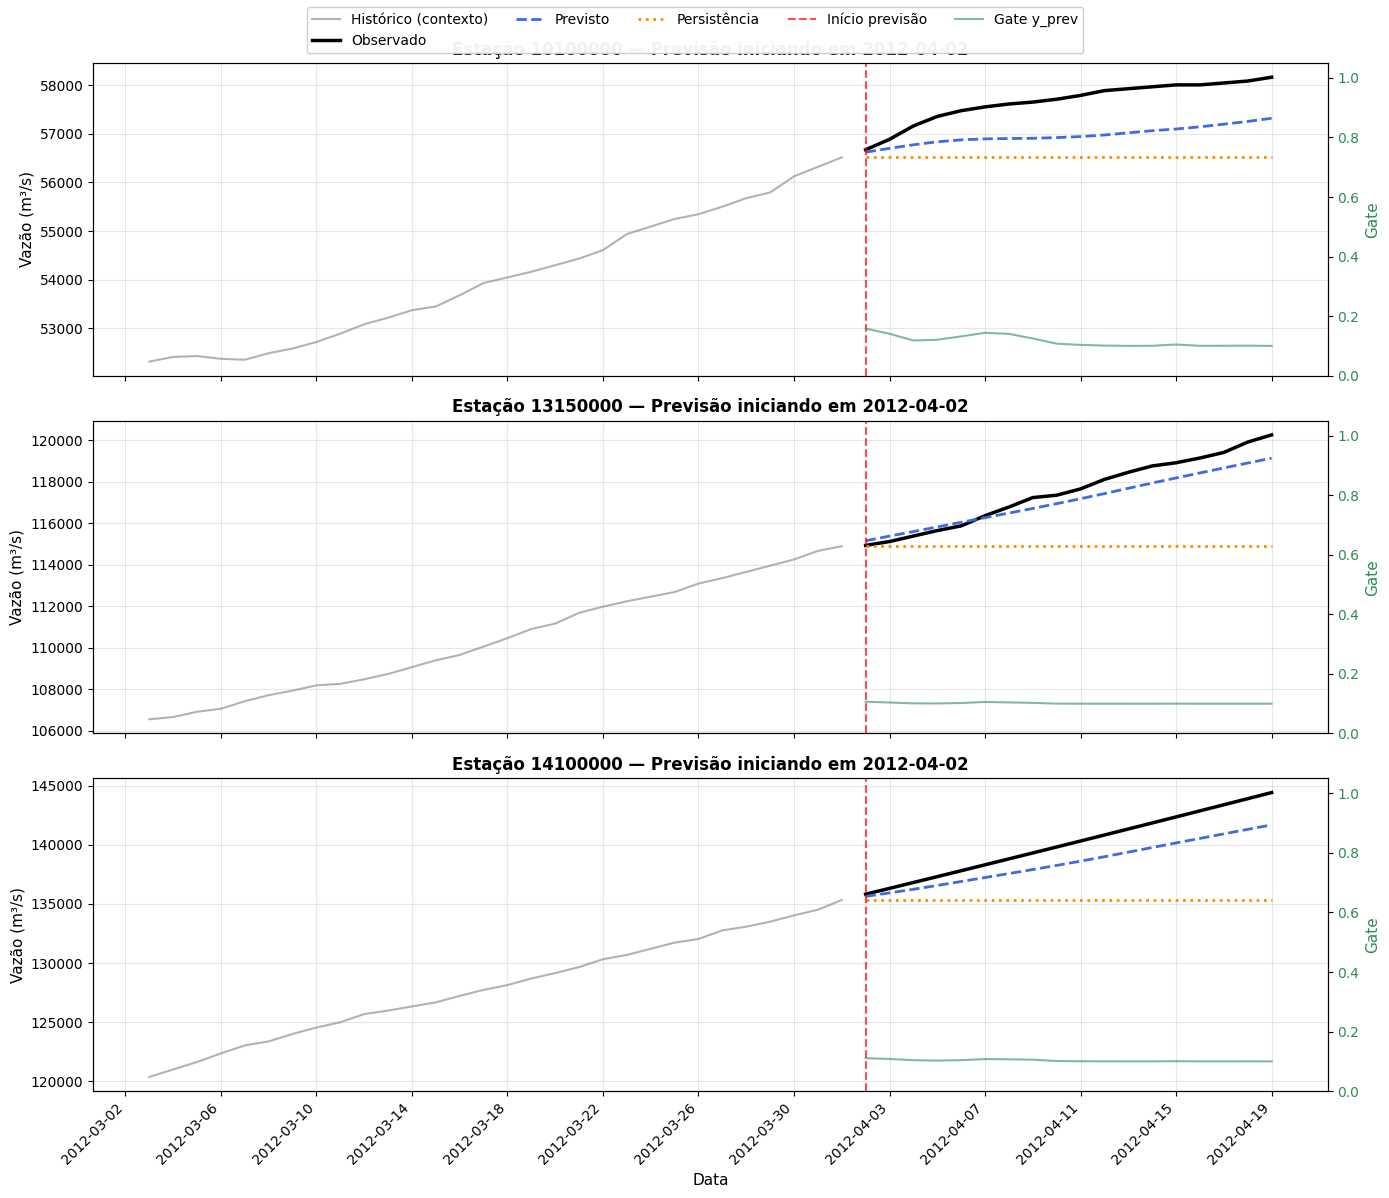

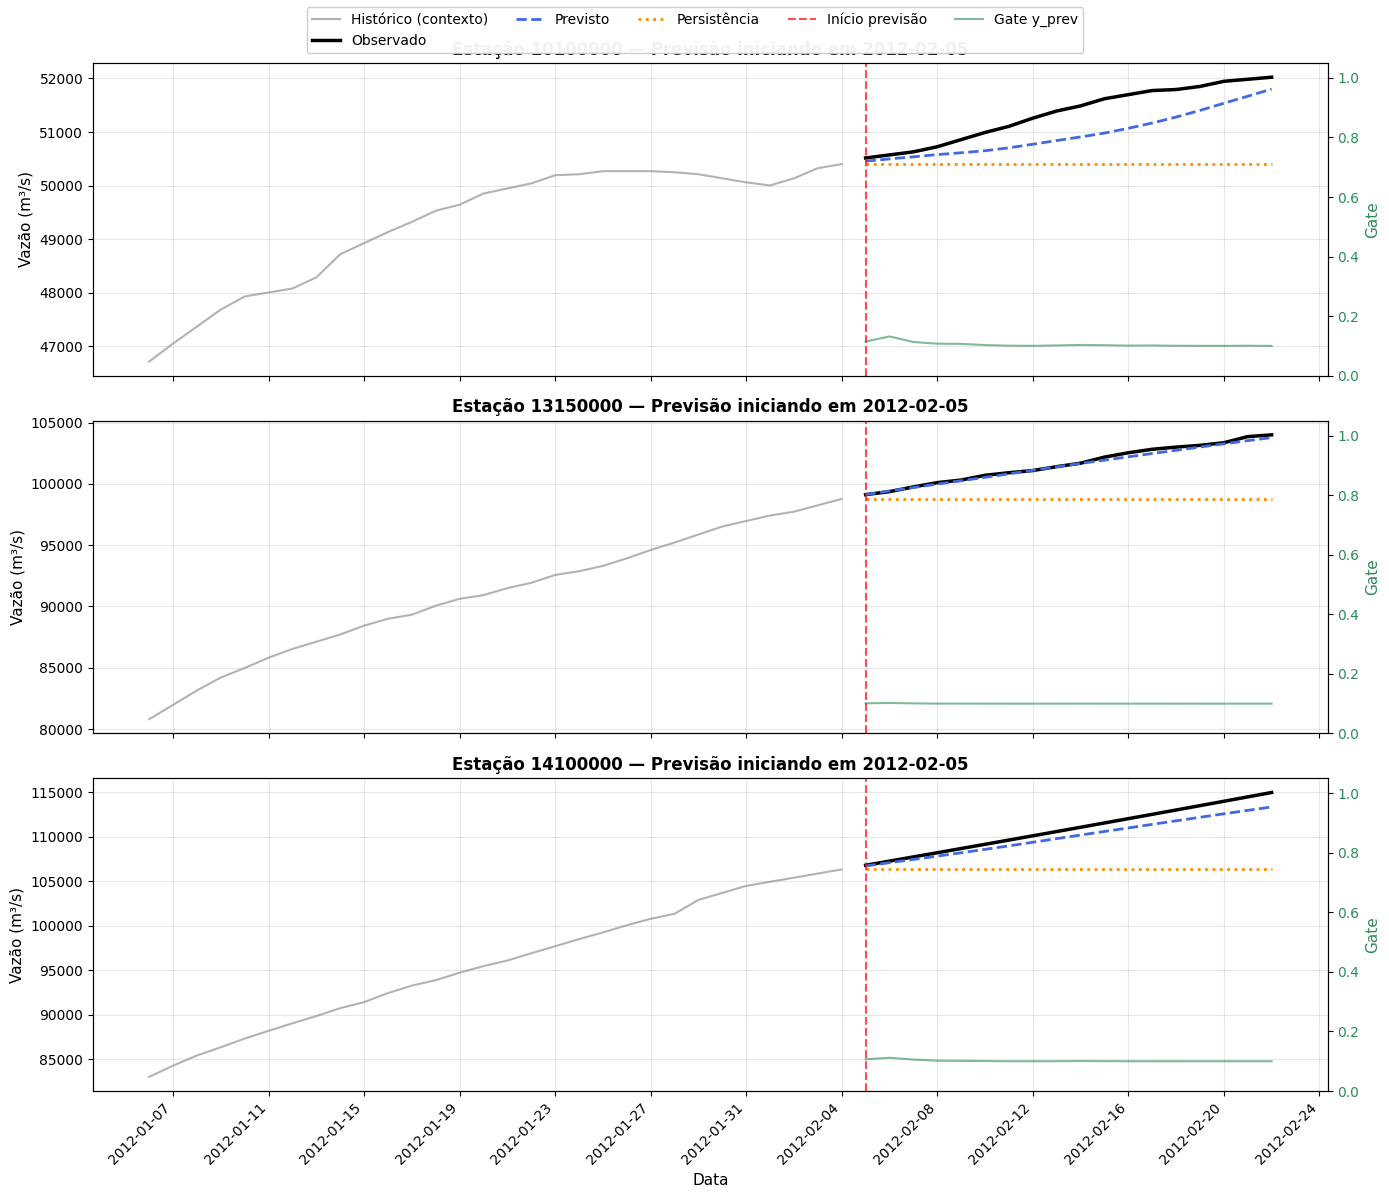

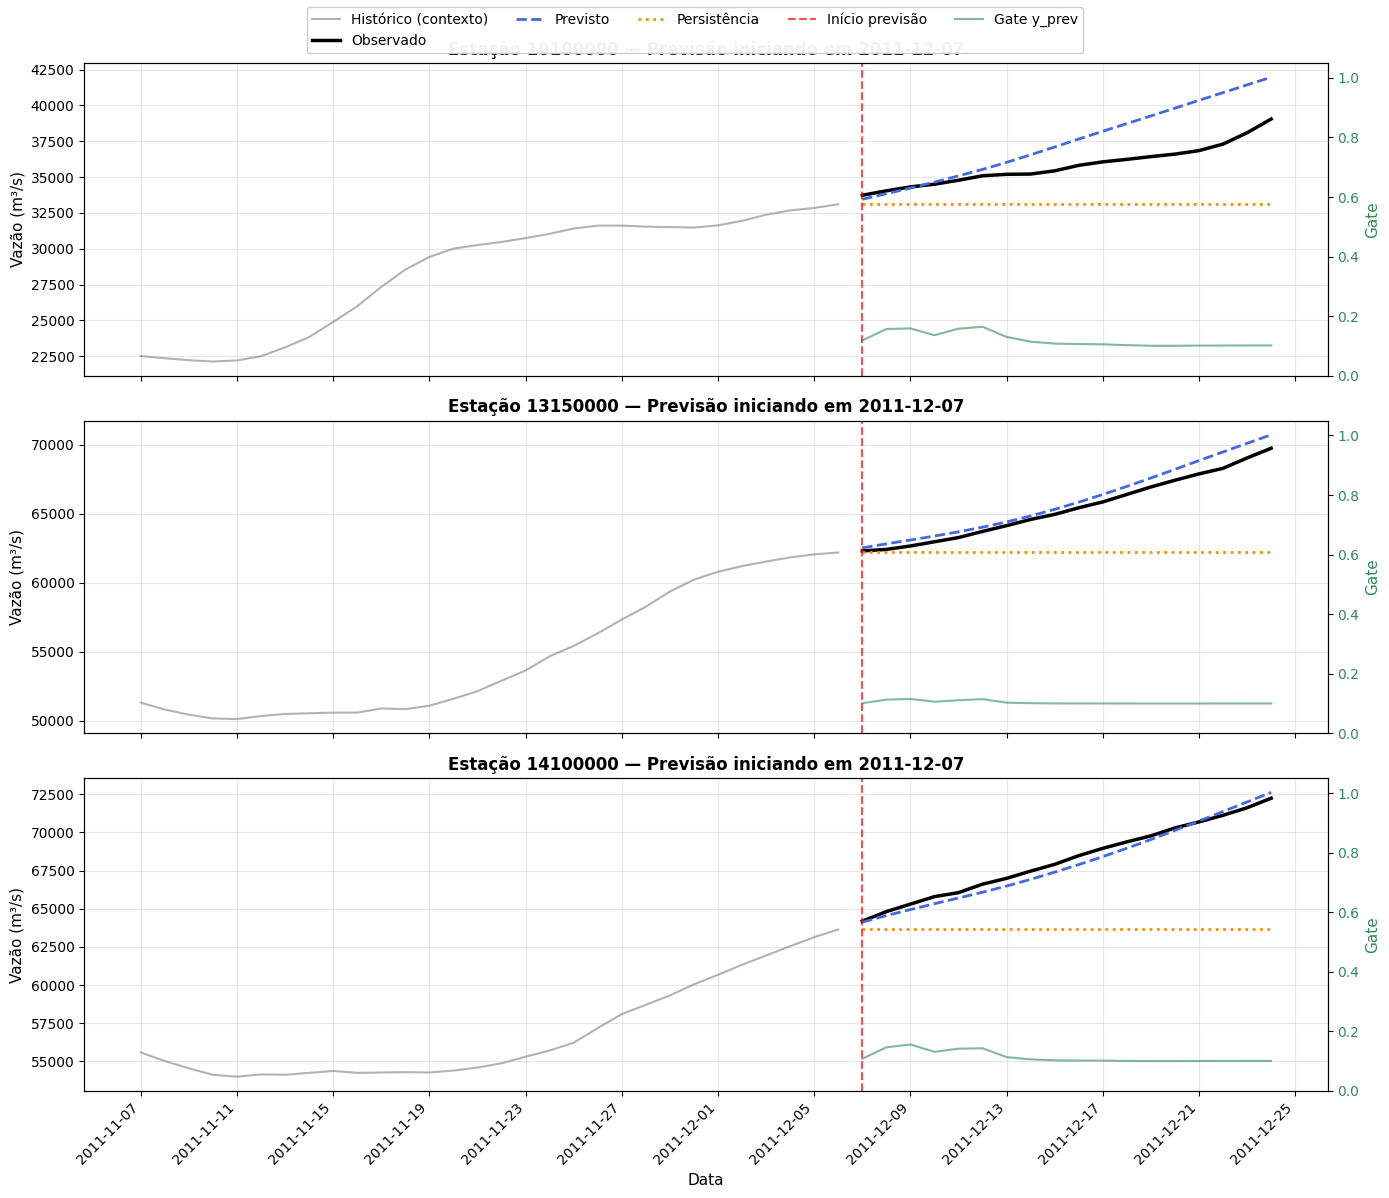

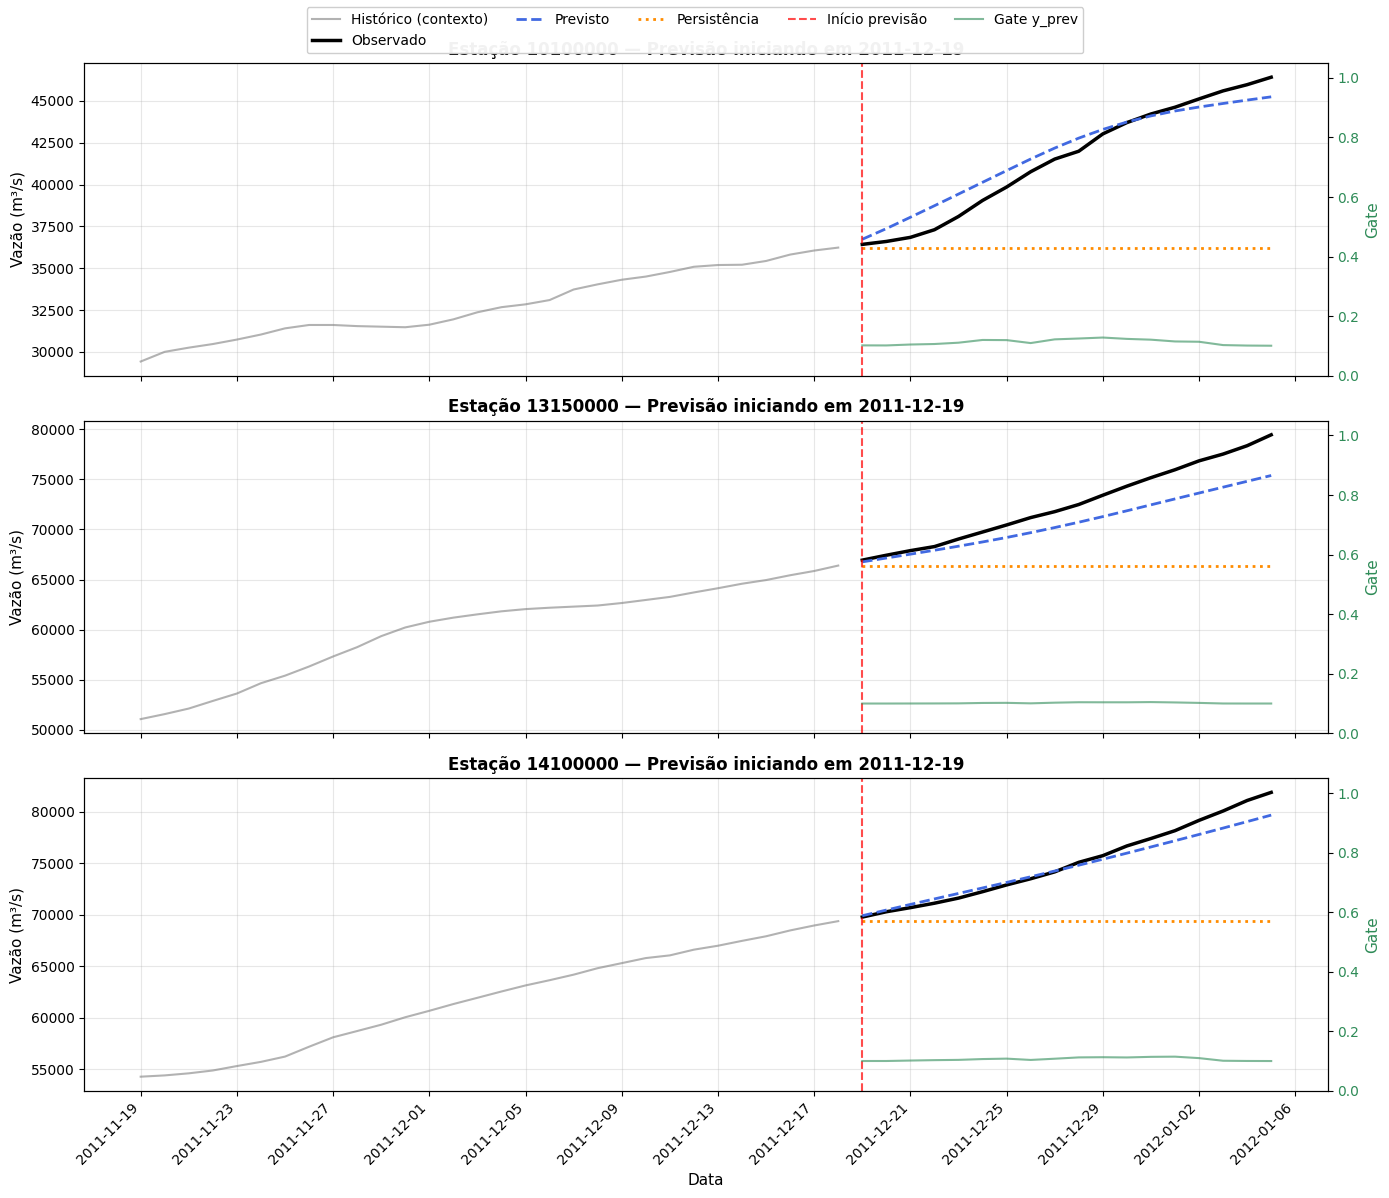

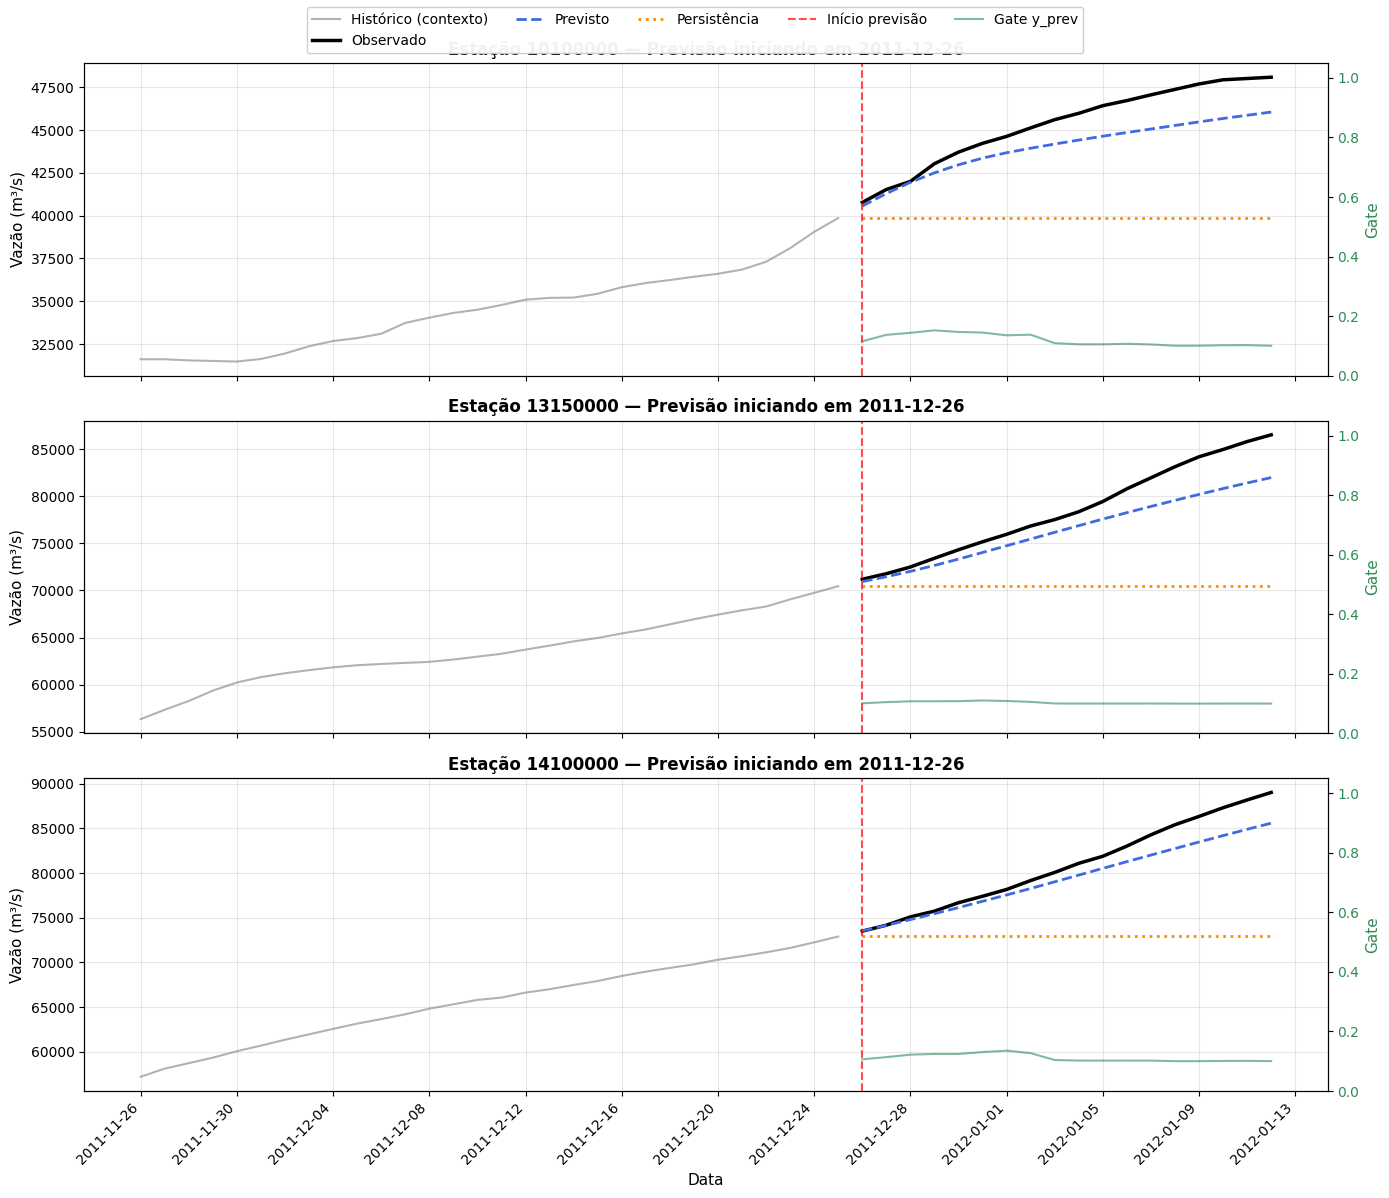

In [ ]:
# 1. Calcular Métricas
print("📊 Calculando métricas...")
metrics = compute_flow_metrics(
    preds=preds,
    obs=obs,
    stations=meta["stations"], # Use meta["stations"] aqui
    baseline_last=baseline
)

# 2. Imprimir Resumo
print_metrics_summary(metrics)

# 3. Plotar Métricas por Horizonte
plot_metrics_by_horizon(metrics, stations=meta["stations"])

# 4. Plotar Previsões com Contexto
print("📈 Gerando gráficos de previsão...")
plot_predictions_with_context(
    preds=preds,
    obs=obs,
    stations=meta["stations"],
    df=combined_df,      # O dataframe original carregado anteriormente
    forecast_dates=dates,
    n_samples=20,         # Quantas amostras aleatórias plotar
    context_days=30,     # Dias de histórico para mostrar
    baseline_last=baseline,
    g_seq=g_seq
)